In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
import matplotlib.patches as patches
import re
import seaborn as sns


In [34]:
tactic_abbr_full = {
    "ttbp":"together_traverse_best_permutation",

    "dor":"divide_over_risks",
    #
    "rndm":"random_walk",

    "hs":"horizontal_scan_traversal",

    "phs":"partitioned_horizontal_scan_traversal",

    "sp": "spiral_traversal_swarm",

    "lb": "lidbetter",
    #
    "toq": "traverse_ordered_qa",

    "tpq":"traverse_p_qa",
    #
    "dd":"discounted_distance",

    "ddr":"discounted_distance_reverse",

    "sl":"shared_list",
}

rename_map = {
    "together_traverse_best_permutation": "Shortest_path_tour",
    "divide_over_risks": "Proportional_risk_split",
    "random_walk": "Random_walk", # Fixed casing for consistency
    "horizontal_scan_traversal": "Horizontal_scan",
    "partitioned_horizontal_scan_traversal": "Partitioned_horizontal_scan",
    "spiral_traversal_swarm": "Inward_spiral",
    "lidbetter": "Lidbetter",
    "traverse_ordered_qa": "Ranked_qa_subset",
    "traverse_p_qa": "Weighted_qa_subset_sampling",
    "discounted_distance": "Risk_weighted_tour",
    "discounted_distance_reverse": "Success_weighted_tour",
    "shared_list": "Dynamic_task_queue",
}
to_plot_tacts_old = list(tactic_abbr_full.values())
to_plot_tacts = [rename_map.get(t, t) for t in to_plot_tacts_old]

In [38]:
# ====================
# CONFIG
# ====================


RESULTS_DICT = {}


Pi_DICT = {
    # Initial settings, before adding multiple sets
                # 1       2       3       4       5       6
    "SUCCESS_PROBABILITIES_INITIAL":
        {"p": [   1/3,    2/3,    3/4,    4/5,    9/10,   95/100],
         "WITH_REPLACEMENT": True
         },

    "SUCCESS_PROBABILITIES_HIGH_VAR":
        {
                # 1       2       3       4       5
        "p": [  0.10,   0.30,   0.60,   0.80,   0.95],
        "WITH_REPLACEMENT": False
        },

    "SUCCESS_PROBABILITIES_LOW_VAR":
                # 1       2       3       4       5
        {"p": [  0.60,   0.62,   0.64,   0.66,   0.68],
         "WITH_REPLACEMENT": False
         },

    "SUCCESS_PROBABILITIES_SKEWED":
                # 1       2       3       4       5
        {"p": [  0.60,    0.62,   0.64,   0.66,   0.10],
         "WITH_REPLACEMENT": False
         },
}

HIDING_STRATEGIES = ['greedy', 'random', 'weighted']  # List of hiding strategies to plot
SWARM_SIZES = [1,5,10]  # List of swarm sizes to plot
N_HIDERS_LIST = [5]  # List of number of hiders to plot
PLOT_DIR = os.path.join("..", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
probability_distributions = Pi_DICT.keys()


FIXED_HIDING_CANDIDATES = 5
FIXED_GRID_WIDTH = 20
FIXED_NUMBER_OF_RUNS = 100000

# For time-based plots
T_MIN = 0
T_MAX = 1000
T_STEP = 10
T_values = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)


HEATMAP_P_DIST = "SUCCESS_PROBABILITIES_LOW_VAR"
# HEATMAP_P_DIST = "SUCCESS_PROBABILITIES_HIGH_VAR"
# HEATMAP_P_DIST = "SUCCESS_PROBABILITIES_SKEWED"

color_theme = "tab10"

def create_palet(n):
    return sns.color_palette(color_theme, n_colors=n)


In [39]:
# File paths
def get_file_name(p_dist, t="SUMMARY_FILENAME"):
    if t == "SUMMARY_FILENAME":
        try:
            return f"../data/dataset/{p_dist}/sim_results_dataset.csv"
        except:
            raise Exception(f"No file named ../data/dataset/{p_dist}/sim_results_dataset.csv")
    else:
        try:
            return f"../data/sim_logs/{p_dist}/"
        except:
            raise Exception(f"No folder named ../data/sim_logs/{p_dist}/")

In [40]:
def create_performance_heatmap(data,
                               distribution_key,
                               swarm_size,
                               metric='P',
                               figsize=(6, 6),
                               title=None,
                               annotate=True,
                               fmt='.3f',
                               tactic_order=None,
                               ax=None,
                               show_xlabel=True,
                               show_xticklabels=True,
                                anchor_rows = False,
                               box_highest = False,
                               ):
    """
    Creates a heatmap of performance (metric P) for hiding strategy vs search tactic
    for a given swarm size and probability distribution.
    """

    # Extract data for one probability distribution
    if distribution_key not in data:
        raise ValueError(f"Distribution '{distribution_key}' not found in data.")
    dist_data = data[distribution_key]

    hiding_strategies = list(dist_data.keys())

    first_hs_list = dist_data[hiding_strategies[0]]

    available_tactics = [t[0] for t in first_hs_list]

    # Force an alphabetical sort for the Master Column Order
    master_tactic_names = sorted(available_tactics)

    # Build performance matrix
    performance_matrix = []
    annotation_matrix = []

    for hs in hiding_strategies:
        hs_data_map = dict(dist_data[hs])

        row_vals = []
        row_text = []

        for tactic_name in master_tactic_names:
            if tactic_name not in hs_data_map:
                raise ValueError(f"Tactic {tactic_name} missing in strategy {hs}")

            stats = hs_data_map[tactic_name]
            swarm_sizes = stats['swarm_sizes']

            if swarm_size not in swarm_sizes:
                raise ValueError(f"Swarm size {swarm_size} not in {tactic_name} for hiding strategy {hs}")

            swarm_idx = np.where(swarm_sizes == swarm_size)[0][0]
            val = stats[metric][swarm_idx]
            low = stats['low'][swarm_idx]
            high = stats['high'][swarm_idx]
            row_vals.append(val)

            label_str = f"{val:.3f}\n[{low:.3f}, {high:.3f}]" # <--- NEW: Format the string
            row_text.append(label_str)

        performance_matrix.append(row_vals)
        annotation_matrix.append(row_text)

    performance_matrix = np.array(performance_matrix)
    annotation_matrix = np.array(annotation_matrix)
    tactic_names = master_tactic_names


    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Row wise normalisation
    row_mins = performance_matrix.min(axis=1, keepdims=True)
    row_maxs = performance_matrix.max(axis=1, keepdims=True)
    divisors = row_maxs - row_mins
    divisors[divisors == 0] = 1

    color_matrix = (performance_matrix - row_mins) / divisors
    annot_data = annotation_matrix if annotate else False
    if anchor_rows:
        sns.heatmap(color_matrix, #normalised rows
                    annot=annot_data, # original data
                    fmt='',
                    xticklabels=tactic_names,
                    yticklabels=hiding_strategies,
                    linewidths=0.25,
                    linecolor='gray',
                    cmap='vlag',
                    ax=ax,
                    cbar=False)
    else:
        # Plot heatmap
        sns.heatmap(performance_matrix,
                    annot=annot_data,
                    fmt='',
                    xticklabels=tactic_names,
                    yticklabels=hiding_strategies,
                    # cbar_kws={'label': cbar_label},
                    linewidths=0.25,
                    linecolor='gray',
                    cmap='vlag',

                    ax=ax,
                    cbar=True)

    rows, cols = performance_matrix.shape
    if box_highest:
        for r in range(rows):
            row_values = performance_matrix[r, :]

            # format all values in the row to strings to ensure matching rounding logic
            row_strs = [f"{x:.3f}" for x in row_values]

            # Find the max value based on the actual numbers, then format it
            max_val_str = f"{np.max(row_values):.3f}"

            # Find all indices where the string representation matches
            max_idxs = [i for i, x in enumerate(row_strs) if x == max_val_str]

            for c in max_idxs:
                rect = patches.Rectangle((c, r), 1, 1,
                                         linewidth=3,
                                         edgecolor='#32CD32',
                                         facecolor='none')
                ax.add_patch(rect)


    if show_xlabel:
        ax.set_xlabel('Search Tactic', fontweight='bold')
    else:
        ax.set_xlabel('')  # Remove x-label if not needed

    if show_xticklabels:
        ax.set_xticklabels(tactic_names, rotation=30, ha='right')
    else:
        ax.set_xticklabels([])  # Remove x-tick labels
    ax.set_ylabel('Hiding Strategy', fontweight='bold')
    ax.tick_params(axis='y', labelrotation=30)

    title = title or f'P(ALL FOUND) (Swarm={swarm_size})'

    if anchor_rows:
        ax.set_title(f"{title}\n(Colors normalized per row)", fontsize=10, pad=20)
    else:
        ax.set_title(title, fontsize=10, pad=20)

    plt.tight_layout()

    return fig, ax


In [41]:
def generate_latex_table(results_object, caption,FIXED_HIDING_STRATEGY):
    """
    Generates a formatted LaTeX table string from a results object.

    Args:
        results_object (list): A list of tuples, where each tuple is
            (tactic_name, data_dict). data_dict contains 'P', 'low', 'high'
            as lists or numpy arrays.
        caption (str): The LaTeX caption for the table.
        label (str): The LaTeX label for the table.
        tactic_order (list, optional): A list of tactic names in the order
            they should appear in the table. If None, it will default to
            a pre-defined order based on the example.

    Returns:
        str: A fully formatted LaTeX table as a string.
    """

    label = f"tab:swarm_performance_{FIXED_HIDING_STRATEGY}"

    # This is the order of tactics as seen in your example tables.
    # We use this to ensure the rows are in the correct order.
    tactic_order = [tup[0] for tup in results_object]

    # Convert the input list of tuples into a dictionary for easy lookup
    data_dict = dict(results_object)

    # Find the maximum 'P' value for each column (swarm size)
    # We initialize with negative infinity to ensure any value is larger
    max_p = [-float('inf'), -float('inf'), -float('inf')]
    num_cols = 3 # Assumes 3 swarm sizes (1, 5, 10)

    for tactic_name in tactic_order:
        if tactic_name in data_dict:
            p_values = data_dict[tactic_name]['P']
            for i in range(num_cols):
                if p_values[i] > max_p[i]:
                    max_p[i] = p_values[i]

    # Start building the LaTeX string
    latex_lines = []
    latex_lines.append(r"\begin{table}[h]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\begin{tabular}{lccc}")
    latex_lines.append(r"\hline")
    latex_lines.append(r"\textbf{Tactic Name} & \textbf{Swarm size 1} & \textbf{Swarm size 5} & \textbf{Swarm size 10} \\")
    latex_lines.append(r"\hline")

    # Iterate through the tactics in the specified order to build rows
    for tactic_name in tactic_order:
        if tactic_name in data_dict:
            data = data_dict[tactic_name]
            P = data['P']
            low = data['low']
            high = data['high']

            # Escape underscores in tactic names for LaTeX
            latex_tactic_name = tactic_name.replace('_', r'\_')

            row_cols = [latex_tactic_name]

            # Format each column value
            for i in range(num_cols):
                val_str = f"{P[i]:.3f} [{low[i]:.3f}, {high[i]:.3f}]"

                # Add \textbf if this is the max value in the column
                if P[i] == max_p[i]:
                    row_cols.append(r"\textbf{" + val_str + r"}")
                else:
                    row_cols.append(val_str)

            # Join all columns with '&' and add the LaTeX line ending
            latex_lines.append(" & ".join(row_cols) + r" \\")

    # Add the table footer
    latex_lines.append(r"\hline")
    latex_lines.append(r"\end{tabular}")
    # Use f-string to insert the caption and label
    latex_lines.append(rf"\caption{{{caption}}}")
    latex_lines.append(rf"\label{{{label}}}")
    latex_lines.append(r"\end{table}")

    # Join all lines with a newline character and return
    return "\n".join(latex_lines)

In [42]:
def obtain_right_data(df_all,hiding_strategy,n_hiders,p_dist):
        df_filtered = df_all[
        (df_all['hide_strategy'] == hiding_strategy) &
        (df_all['n_hiders'] == n_hiders) &
        (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
        (df_all['grid_width'] == FIXED_GRID_WIDTH) &
        (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
        ]

        if df_filtered.empty:
            print(f"No data for HS={hiding_strategy}, Hiders={n_hiders}")
            return None

        all_swarm_sizes = sorted(df_filtered['swarm_size'].unique())
        results = {}

        for tactic_name in df_filtered['tactic'].unique():
            df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]
            df_tactic = df_tactic.sort_values(by='swarm_size')

            results[tactic_name] = {
                'swarm_sizes': df_tactic['swarm_size'].values,
                'P': df_tactic['all_found_mean'].values,
                'low': df_tactic['all_found_ci_lower'].values,
                'high': df_tactic['all_found_ci_upper'].values
            }

        # print(results)

        sorted_results = sorted(
                results.items(),
                key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
                reverse=True
        )

        if p_dist not in RESULTS_DICT:
            RESULTS_DICT[p_dist] = {}
        RESULTS_DICT[p_dist][hiding_strategy] = sorted_results


In [43]:
to_plot_tacts = list(tactic_abbr_full.values())

In [44]:
for p_dist in probability_distributions:
    if p_dist == "SUCCESS_PROBABILITIES_INITIAL":
        continue

    print("Loading data...")
    df_all = pd.read_csv(get_file_name(p_dist,t="SUMMARY_FILENAME"))

    df_all = df_all[df_all['tactic'].isin(to_plot_tacts_old)]

    # 2. Rename the tactics in the DataFrame column
    df_all['tactic'] = df_all['tactic'].replace(rename_map)
    # --- CHANGE END ---

    # Now proceed as normal (obtain_right_data will now see the new names)
    print("\nGenerating Probability vs Swarm Size plots...")

    # Generate Probability vs Swarm Size plots
    print("\nGenerating Probability vs Swarm Size plots...")
    for hiding_strategy in HIDING_STRATEGIES:
        for n_hiders in N_HIDERS_LIST:
            # print(f"  - HS={hiding_strategy}, Hiders={n_hiders}")
            res = obtain_right_data(df_all, hiding_strategy, n_hiders, p_dist)


Loading data...

Generating Probability vs Swarm Size plots...

Generating Probability vs Swarm Size plots...
Loading data...

Generating Probability vs Swarm Size plots...

Generating Probability vs Swarm Size plots...
Loading data...

Generating Probability vs Swarm Size plots...

Generating Probability vs Swarm Size plots...



Generating stacked heatmap figure...


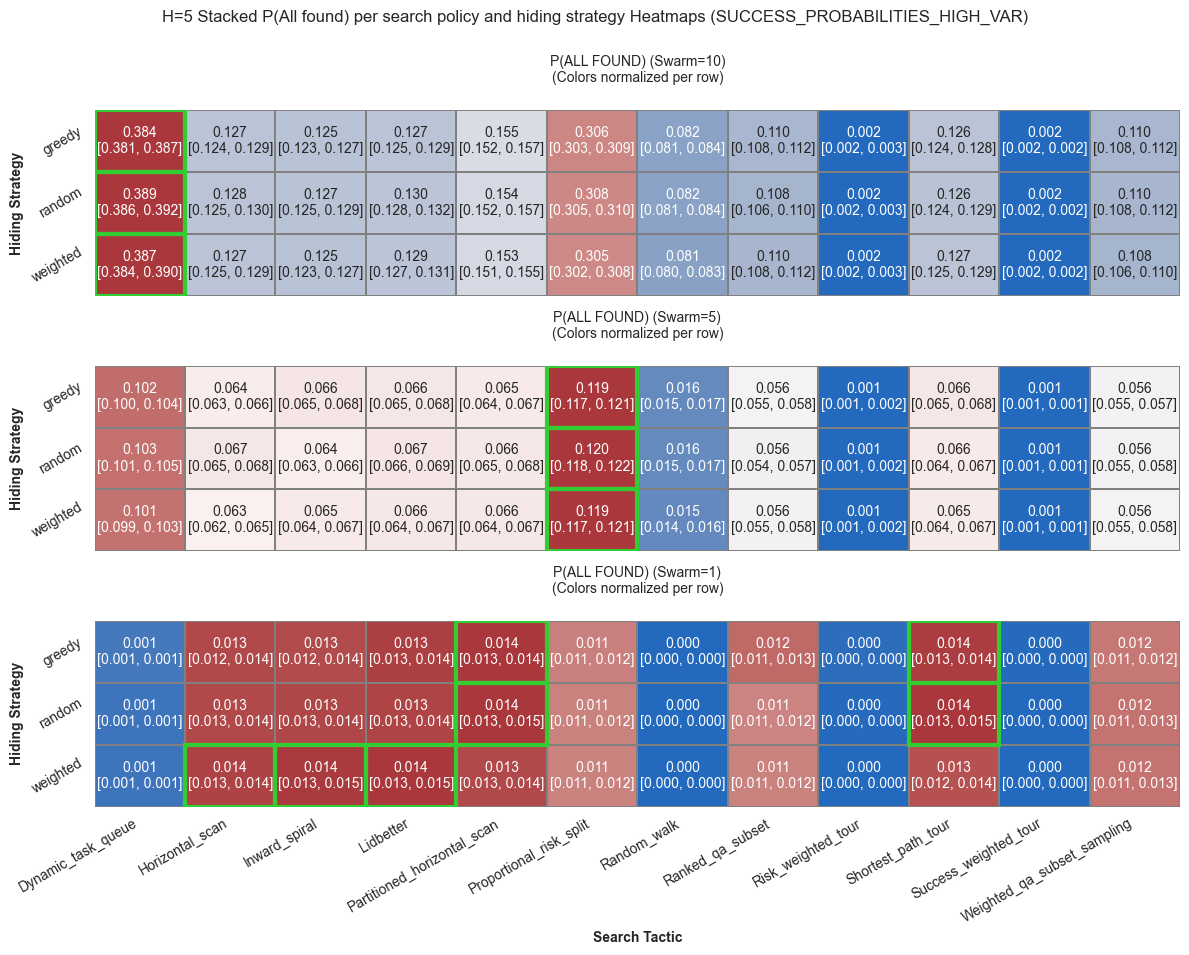


Generating stacked heatmap figure...


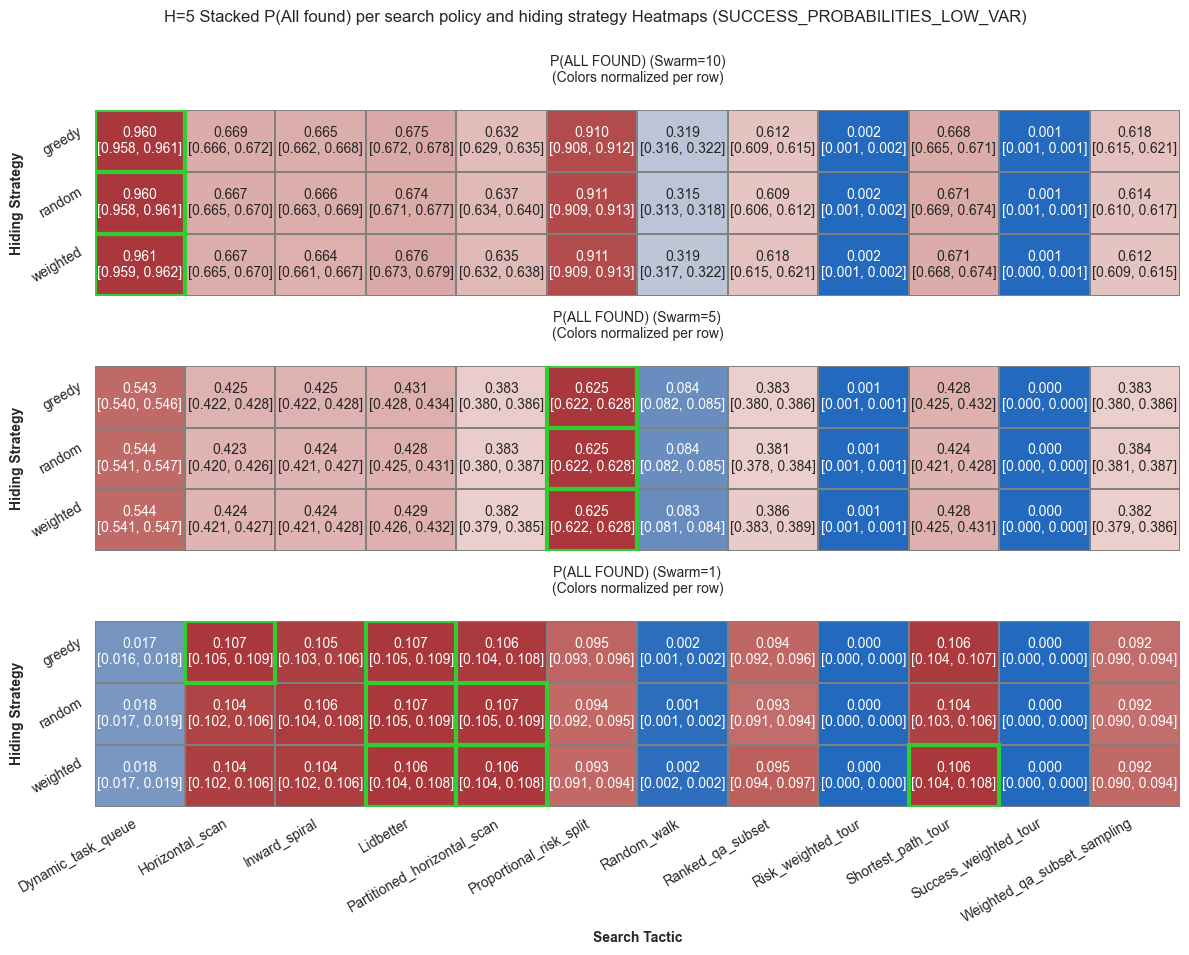


Generating stacked heatmap figure...


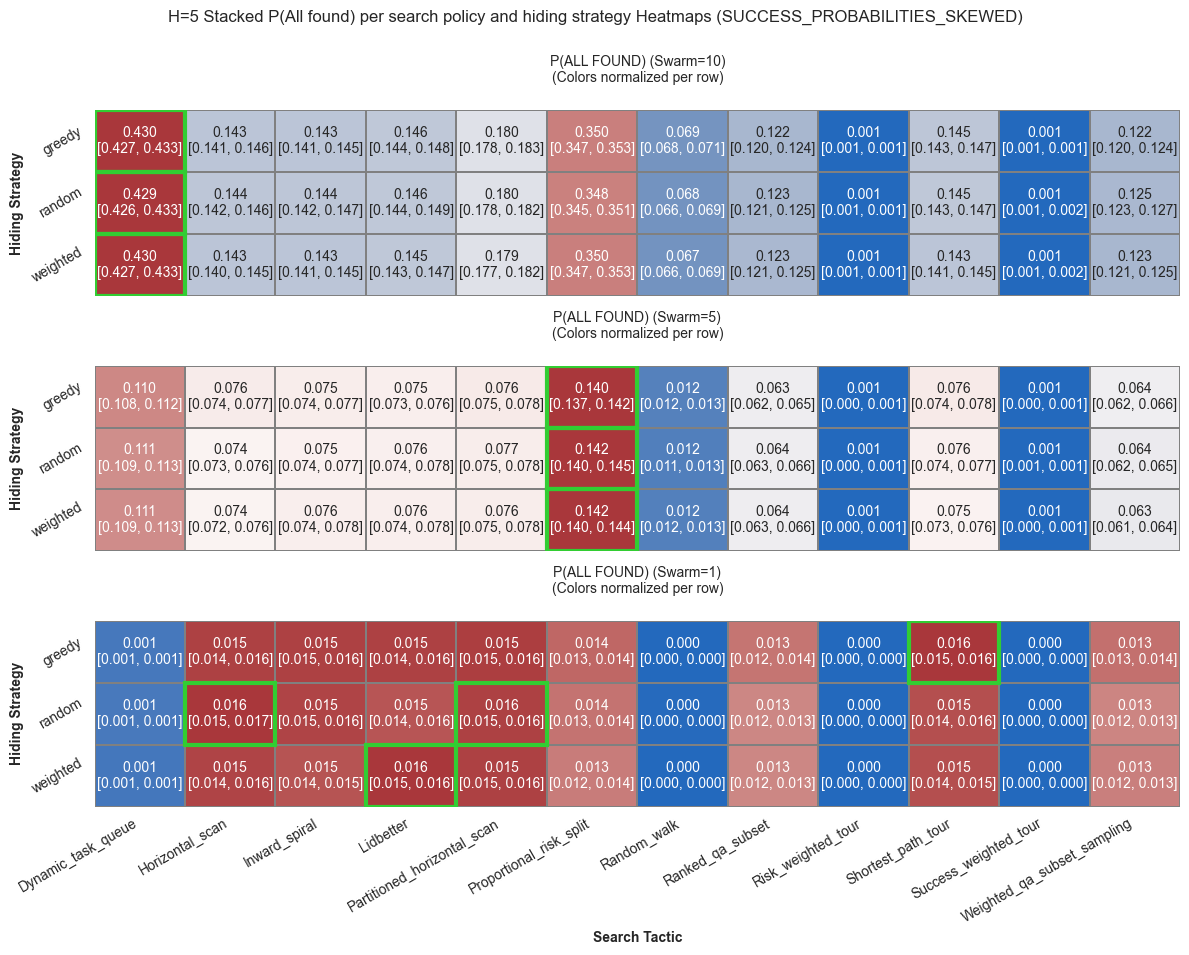

In [45]:
for dist_key in probability_distributions:
        if dist_key == "SUCCESS_PROBABILITIES_INITIAL":
            continue


        print("\nGenerating stacked heatmap figure...")
        swarm_sizes_to_plot = [10, 5,1]
        num_plots = len(swarm_sizes_to_plot)

        fig, axes = plt.subplots(nrows=num_plots,
                                 ncols=1,
                                 figsize=(12,10),  # Taller figure (e.g., 6 inches per plot)
                                 sharex=True)

        if num_plots == 1:
            axes = [axes]

        # Loop through the axes and swarm sizes to create each plot
        for i, swarm_size in enumerate(swarm_sizes_to_plot):
            ax = axes[i]  # Get the current subplot axis

            # Determine if this is the bottom-most plot
            is_last_plot = (i == num_plots - 1)

            # Call the modified function
            create_performance_heatmap(
                data=RESULTS_DICT,
                distribution_key=dist_key,
                swarm_size=swarm_size,
                ax=ax,
                show_xlabel=is_last_plot,
                show_xticklabels=is_last_plot,
                anchor_rows=True,
                box_highest=True
            )

        # Add an overall title to the entire figure
        fig.suptitle(f'H={N_HIDERS_LIST[0]} Stacked P(All found) per search policy and hiding strategy Heatmaps ({dist_key})', fontsize=12)

        fig.tight_layout(rect=[0, 0.03, 1, 0.98])

        # Save and show the final stacked figure
        file_path = os.path.join("..", "plots",f"H{N_HIDERS_LIST[0]}",f"full_stacked_heatmap_figure_{dist_key}.svg")
        plt.savefig(file_path, bbox_inches='tight')
        plt.show()







Generating stacked heatmap figure...


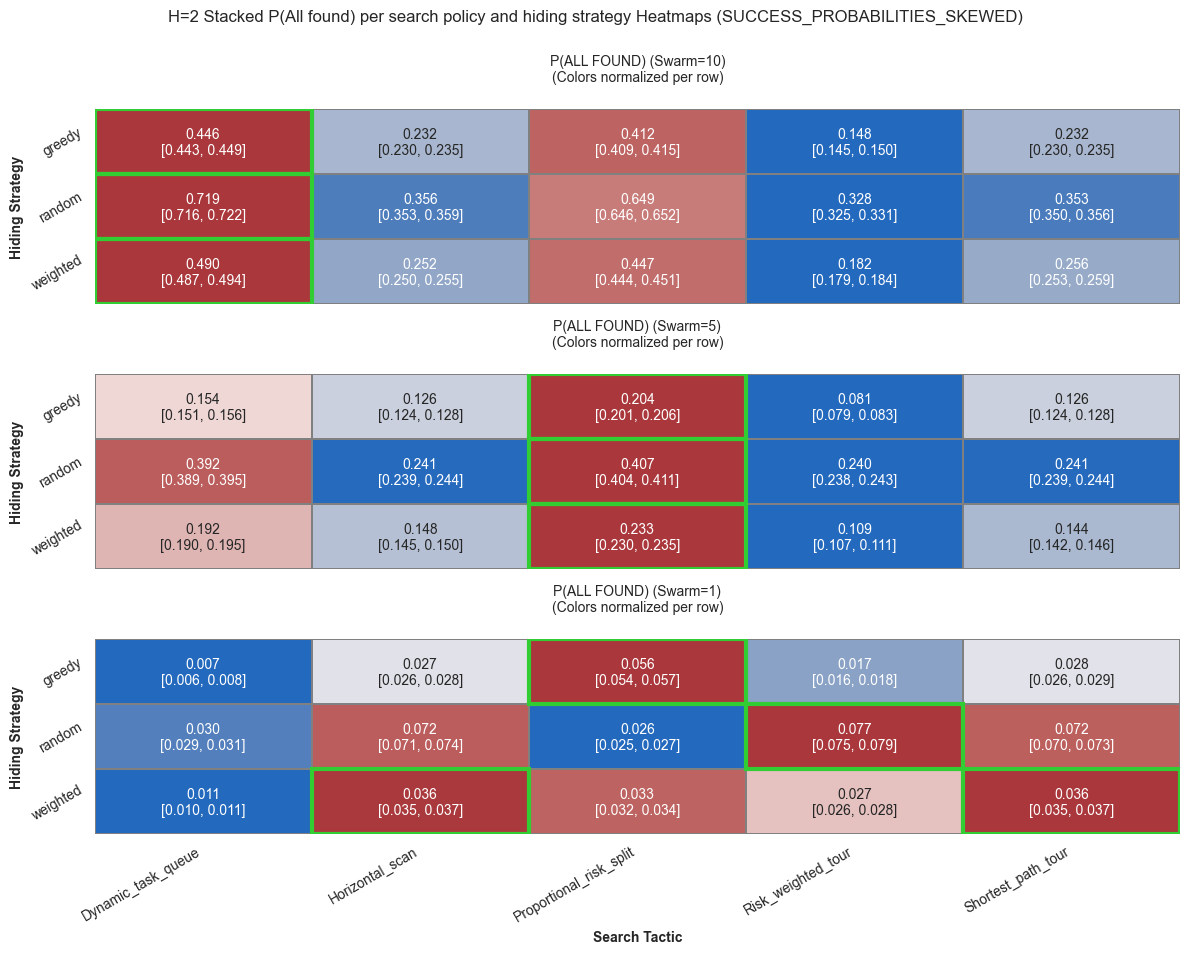

saved at ..\plots\SUCCESS_PROBABILITIES_SKEWED\H2\stacked_heatmap_figure_SUCCESS_PROBABILITIES_SKEWED_H2.svg


In [155]:

dist_key = HEATMAP_P_DIST

print("\nGenerating stacked heatmap figure...")
swarm_sizes_to_plot = [10, 5,1]
num_plots = len(swarm_sizes_to_plot)

fig, axes = plt.subplots(nrows=num_plots,
                         ncols=1,
                         figsize=(12,10),  # Taller figure (e.g., 6 inches per plot)
                         sharex=True)

if num_plots == 1:
    axes = [axes]

# Loop through the axes and swarm sizes to create each plot
for i, swarm_size in enumerate(swarm_sizes_to_plot):
    ax = axes[i]  # Get the current subplot axis

    # Determine if this is the bottom-most plot
    is_last_plot = (i == num_plots - 1)

    # Call the modified function
    create_performance_heatmap(
        data=RESULTS_DICT,
        distribution_key=dist_key,
        swarm_size=swarm_size,
        ax=ax,
        show_xlabel=is_last_plot,
        show_xticklabels=is_last_plot,
        anchor_rows=True,
        box_highest=True
    )

# Add an overall title to the entire figure
fig.suptitle(f'H={N_HIDERS_LIST[0]} Stacked P(All found) per search policy and hiding strategy Heatmaps ({dist_key})', fontsize=12)

fig.tight_layout(rect=[0, 0.03, 1, 0.98])

# Save and show the final stacked figure
file_path = os.path.join("..", "plots", f"{dist_key}",f"H{N_HIDERS_LIST[0]}",f"stacked_heatmap_figure_{dist_key}_H{N_HIDERS_LIST[0]}.svg")
plt.savefig(file_path, bbox_inches='tight')
plt.show()
print("saved at",file_path)





In [194]:
# # ==========================================
# # STACKED BAR CHART GENERATION
# # ==========================================
#
# def plot_stacked_bar_by_swarm(results_dict, dist_key, swarm_sizes, hiding_strategies, sort_by_total=True):
#     """
#     Generates a figure with subplots for each swarm size.
#     Each subplot shows the Cumulative Score (Stacked by Hiding Strategy) for every Tactic.
#     """
#
#     # 1. Flatten the dictionary into a Pandas DataFrame
#     data_rows = []
#
#     # Check if data exists
#     if dist_key not in results_dict:
#         print(f"Key {dist_key} not found in results.")
#         return
#
#     dist_data = results_dict[dist_key]
#
#     for hs in hiding_strategies:
#         if hs not in dist_data: continue
#
#         # dist_data[hs] is a list of tuples: (tactic_name, stats_dict)
#         for tactic_name, stats in dist_data[hs]:
#             available_sizes = stats['swarm_sizes']
#             p_values = stats['P']
#
#             for i, size in enumerate(available_sizes):
#                 if size in swarm_sizes:
#                     data_rows.append({
#                         'Tactic': tactic_name,
#                         'Hiding Strategy': hs,
#                         'Swarm Size': size,
#                         'Score': p_values[i]
#                     })
#
#     df = pd.DataFrame(data_rows)
#
#     if df.empty:
#         print("No data found for the specified configuration.")
#         return
#
#     # 2. Setup the Plot
#     num_sizes = len(swarm_sizes)
#     fig, axes = plt.subplots(nrows=1, ncols=num_sizes, figsize=(18, 6), sharey=True)
#     if num_sizes == 1: axes = [axes]
#
#     # Define colors for hiding strategies to ensure consistency across plots
#     # Using a soft, distinct palette
#     colors = create_palet(3)
#
#     # Map the colors to your strategies.
#     # Index 0 is the darkest color, Index 2 is the lightest.
#
#     color_map = {hs: colors[i % len(colors)] for i, hs in enumerate(hiding_strategies)}
#
#     # 3. Determine Sorting Order (Optional but recommended)
#     # We sort tactics based on the Total Sum of Scores across ALL swarm sizes and strategies
#     # This keeps the x-axis order consistent across the 3 plots
#     if sort_by_total:
#         total_scores = df.groupby('Tactic')['Score'].sum().sort_values(ascending=False)
#         tactic_order = total_scores.index.tolist()
#     else:
#         tactic_order = df['Tactic'].unique().tolist()
#
#     # 4. Generate Subplots
#     for i, size in enumerate(sorted(swarm_sizes)):
#         ax = axes[i]
#
#         # Filter data for this swarm size
#         subset = df[df['Swarm Size'] == size]
#
#         # Pivot: Index=Tactic, Columns=Hiding Strategy, Values=Score
#         pivot_df = subset.pivot(index='Tactic', columns='Hiding Strategy', values='Score')
#
#         # Reindex to ensure sorted order and fill missing with 0
#         pivot_df = pivot_df.reindex(tactic_order).fillna(0)
#
#         # Ensure columns (stack layers) are in the defined order
#         pivot_df = pivot_df[hiding_strategies]
#
#         # Plot
#         pivot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_map.get(x) for x in hiding_strategies], width=0.8)
#
#
#         # Formatting
#         ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold')
#         ax.set_xlabel("")
#         if i == 0:
#             ax.set_ylabel("Cumulative Probability (Sum of P)", fontsize=12)
#
#         # Clean up x-labels
#         ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=10)
#
#         ax.grid(axis='y', linestyle='--', alpha=0.5)
#
#         ax.get_legend().remove()
#
#     # Create a unified legend at the top
#     handles = [patches.Patch(color=color_map[hs], label=hs) for hs in hiding_strategies]
#     fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, title="Hiding Strategy",
#                fontsize=12)
#
#     plt.suptitle(f"Robustness Analysis: Cumulative Performance by Swarm Size\nDistribution: {dist_key}", y=1.10,
#                  fontsize=16)
#     plt.tight_layout()
#
#     # Save
#     save_path = os.path.join(PLOT_DIR, f"stacked_bar_robustness_{dist_key}.svg")
#     #  plt.savefig(save_path, bbox_inches='tight')
#     print(f"Plot saved to {save_path}")
#     plt.show()
#
#
# # ==========================================
# # EXECUTE PLOT
# # ==========================================
#
# # Using the currently selected distribution from your config
# dist_key_to_plot = HEATMAP_P_DIST
#
# plot_stacked_bar_by_swarm(
#     results_dict=RESULTS_DICT,
#     dist_key=dist_key_to_plot,
#     swarm_sizes=[1, 5, 10],
#     hiding_strategies=['greedy', 'random', 'weighted']
# )

Plot saved to ..\plots\SUCCESS_PROBABILITIES_SKEWED\H5\horizontal_robustness_SUCCESS_PROBABILITIES_SKEWED_H5.svg


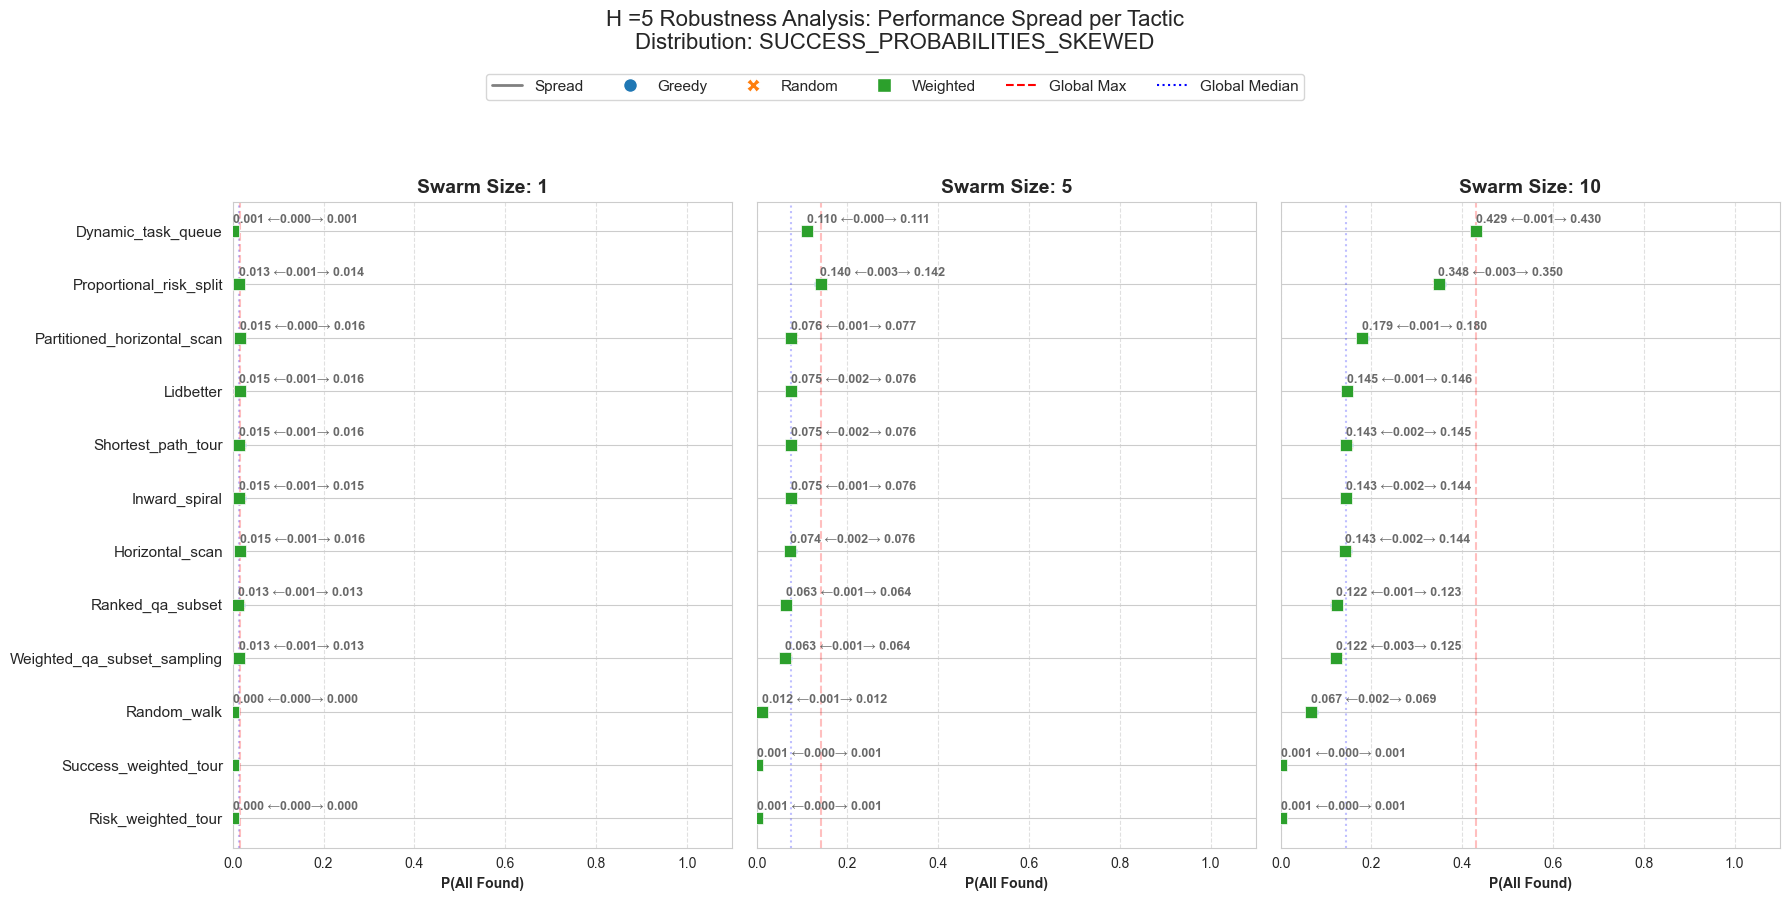

In [93]:
import matplotlib.lines as mlines

def plot_horizontal_robustness(results_dict, dist_key, swarm_sizes, hiding_strategies, show_values=True):
    """
    Generates a Horizontal Point Plot with fixed legend and optional value labels.
    """
    # 1. Data Wrangling
    data_rows = []
    if dist_key not in results_dict:
        print(f"Key {dist_key} not found.")
        return

    dist_data = results_dict[dist_key]

    for hs in hiding_strategies:
        if hs not in dist_data: continue
        for tactic_name, stats in dist_data[hs]:
            available_sizes = stats['swarm_sizes']
            p_values = stats['P']
            for i, size in enumerate(available_sizes):
                if size in swarm_sizes:
                    data_rows.append({
                        'Tactic': tactic_name, 'Hiding Strategy': hs,
                        'Swarm Size': size, 'Score': p_values[i]
                    })

    df = pd.DataFrame(data_rows)
    if df.empty: return

    # 2. Sort Order (Mean Score)
    tactic_order = df.groupby('Tactic')['Score'].mean().sort_values(ascending=True).index.tolist()

    # 3. Setup Plot
    num_sizes = len(swarm_sizes)
    fig, axes = plt.subplots(nrows=1, ncols=num_sizes, figsize=(18, 8), sharey=True)
    if num_sizes == 1: axes = [axes]

    palet_obj = create_palet(3)
    strategy_colors = {
        'greedy': palet_obj[0],   # Darkest
        'random': palet_obj[1],   # Medium
        'weighted': palet_obj[2]  # Lightest
    }
    markers = {'greedy': 'o', 'random': 'X', 'weighted': 's'}

    # 4. Plotting Loop
    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]
        subset = df[df['Swarm Size'] == size]

        # Calculate global benchmarks for this swarm size
        global_median = subset['Score'].median()
        global_max = subset['Score'].max()

        for y_idx, tactic in enumerate(tactic_order):
            tactic_data = subset[subset['Tactic'] == tactic]
            if tactic_data.empty: continue

            scores = tactic_data['Score'].values
            min_score = scores.min()
            max_score = scores.max()
            # A. Draw the "Spread" line
            ax.hlines(y=y_idx, xmin=min_score, xmax=max_score,
                      color='gray', alpha=0.5, linewidth=2, zorder=1)



            spread = max_score - min_score

            midpoint = (min_score + max_score) / 2
            # Draw the line
            ax.hlines(y=y_idx, xmin=min_score, xmax=max_score,
                      color='gray', alpha=0.4, linewidth=3, zorder=1)

            height = 0.1

            overlap_threshold = 0.2

            if spread > 0.00001:

                is_near_right_edge = max_score > 0.83

                if spread < overlap_threshold:
                    combined_text = f"{min_score:.3f} ←{spread:.3f}→ {max_score:.3f}"

                    if is_near_right_edge:
                        ax.text(x=max_score, y=y_idx + 0.10, s=combined_text,
                                ha='right', va='bottom', fontsize=9,
                                color='dimgray', fontweight='bold')
                    else:
                        ax.text(x=min_score, y=y_idx + 0.10, s=combined_text,
                                ha='left', va='bottom', fontsize=9,
                                color='dimgray', fontweight='bold')

                else:


                    # Midpoint spread label
                    ax.text(x=midpoint, y=y_idx + 0.10, s=f"←{spread:.3f}→",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                    # Min score label (usually fine)
                    ax.text(x=min_score, y=y_idx + 0.10, s=f"{min_score:.3f}",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                    # Max score label - prevent overflow here too
                    max_align = 'right' if max_score > 0.95 else 'center'

                    ax.text(x=max_score, y=y_idx + 0.10, s=f"{max_score:.3f}",
                            ha=max_align, va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')



            # B. Plot the specific points & Optional Labels
            for _, row in tactic_data.iterrows():
                hs = row['Hiding Strategy']
                score = row['Score']

                # Plot Dot
                ax.scatter(x=score, y=y_idx,
                           color=strategy_colors.get(hs, 'black'),
                           marker=markers.get(hs, 'o'),
                           s=80, zorder=3, edgecolors='white', linewidth=0.5)

                # --- NEW: Add Value Labels ---
                # Only adding label if show_values is True.
                # We offset y by +0.15 to put text slightly above the dot.
                if show_values:
                    ax.text(x=score, y=y_idx + 0.7, s=f"{score:.2f}",
                            ha='center', va='bottom', fontsize=8,
                            color=strategy_colors.get(hs, 'black'), fontweight='bold')

        # Add Global Benchmarks
        ax.axvline(global_median, color='blue', linestyle=':', alpha=0.25)
        ax.axvline(global_max, color='red', linestyle='--', alpha=0.25)

        # Formatting
        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold')
        ax.set_xlabel("P(All Found)", fontweight='bold')
        ax.set_yticks(range(len(tactic_order)))

        if i == 0:
            ax.set_yticklabels(tactic_order, fontsize=11)

        ax.grid(axis='x', linestyle='--', alpha=0.6)
        ax.set_xlim(0, 1.1) # Added space for labels


    handles = [
        mlines.Line2D([], [], color='gray', lw=2, label='Spread'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor=strategy_colors['greedy'], label='Greedy', markersize=10),
        mlines.Line2D([], [], marker='X', color='w', markerfacecolor=strategy_colors['random'], label='Random', markersize=10),
        mlines.Line2D([], [], marker='s', color='w', markerfacecolor=strategy_colors['weighted'], label='Weighted', markersize=10),
        # FIXED LINES BELOW:
        mlines.Line2D([], [], linestyle='--', color='r', label='Global Max'),
        mlines.Line2D([], [], linestyle=':', color='b', label='Global Median'),
    ]

    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=6, fontsize=11)
    plt.suptitle(f"H ={N_HIDERS_LIST[0]} Robustness Analysis: Performance Spread per Tactic\nDistribution: {dist_key}", y=1.12, fontsize=16)
    plt.tight_layout()




    file_path = os.path.join("..", "plots", f"{dist_key}",f"H{N_HIDERS_LIST[0]}",f"horizontal_robustness_{dist_key}_H{N_HIDERS_LIST[0]}.svg")


    plt.savefig(file_path, bbox_inches='tight')

    print(f"Plot saved to {file_path}")

    plt.show()



# Execute
plot_horizontal_robustness(
    results_dict=RESULTS_DICT,
    dist_key=HEATMAP_P_DIST,
    swarm_sizes=[1, 5, 10],
    hiding_strategies=['greedy', 'random', 'weighted'],
    show_values=False
)



In [24]:

# ==========================================
#         DATA EXTRACTION FUNCTION
# ==========================================
def obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist):
    # Filter the dataframe based on the function arguments and global constants
    mask = (
        (df_all['hide_strategy'] == hiding_strategy) &
        (df_all['n_hiders'] == n_hiders) &
        (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
        (df_all['grid_width'] == FIXED_GRID_WIDTH) &
        (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
    )

    df_filtered = df_all[mask]

    if df_filtered.empty:
        return None

    results = {}

    for tactic_name in df_filtered['tactic'].unique():
        df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]
        df_tactic = df_tactic.sort_values(by='swarm_size')

        results[tactic_name] = {
            'swarm_sizes': df_tactic['swarm_size'].values,
            'P': df_tactic['all_found_mean'].values,
            'low': df_tactic['all_found_ci_lower'].values,
            'high': df_tactic['all_found_ci_upper'].values
        }

    sorted_results = sorted(
        results.items(),
        key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
        reverse=True
    )

    return sorted_results

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns


# ==========================================
#            PLOTTING FUNCTION
# ==========================================
def plot_robustness_by_hiders(df, dist_name, swarm_sizes=[1, 5, 10]):
    """
    Robustness Cleveland Dot Plot for a SINGLE Distribution.
    """

    # Filter data for requested swarm sizes AND the specific distribution
    df = df[(df['Swarm Size'].isin(swarm_sizes)) & (df['Distribution'] == dist_name)]

    if df.empty:
        print(f"No data available for distribution: {dist_name}")
        return

    # --- DEFINE COLORS FOR HIDERS ---
    unique_hiders = sorted(df['Hiders'].unique())

    palette_obj = create_palet(len(unique_hiders))
    hider_colors = {h: palette_obj[i] for i, h in enumerate(unique_hiders)}

    strat_markers = {
        'greedy': 'o',
        'random': 'X',
        'weighted': 's'
    }

    # Sort Tactics by Global Median Score within this distribution
    if 'Score' not in df.columns:
        print("Error: 'Score' column missing")
        return

    tactic_order = df.groupby('Tactic')['Score'].median().sort_values(ascending=True).index.tolist()

    # Setup Figure
    num_sizes = len(swarm_sizes)
    fig, axes = plt.subplots(nrows=1, ncols=num_sizes, figsize=(20, 10), sharey=True)
    if num_sizes == 1: axes = [axes]

    # --- PLOTTING LOOP ---
    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]
        subset = df[df['Swarm Size'] == size]

        # Calculate Global Benchmarks for this Swarm Size
        global_median = subset['Score'].median()
        global_max = subset['Score'].max()

        # Grid and Background
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        ax.set_facecolor('#f9f9f9')

        # --- 1. PLOT GLOBAL LINES ---
        # Global Median
        ax.axvline(x=global_median, color='blue', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        # Global Max
        ax.axvline(x=global_max, color='red', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

        # --- 2. DRAW SPREAD LINES AND LABELS ---
        for y_idx, tactic in enumerate(tactic_order):
            tactic_data = subset[subset['Tactic'] == tactic]
            if tactic_data.empty: continue

            min_score = tactic_data['Score'].min()
            max_score = tactic_data['Score'].max()
            spread = max_score - min_score
            midpoint = (min_score + max_score) / 2
            # Draw gray line representing robustness range
            ax.hlines(y=y_idx, xmin=min_score, xmax=max_score,
                      color='gray', alpha=0.4, linewidth=3, zorder=1)


            overlap_threshold = 0.2

            if spread > 0.001:

                if spread < overlap_threshold:

                    combined_text = f"{min_score:.3f} ←{spread:.3f}→ {max_score:.3f}"

                    ax.text(x=min_score, y=y_idx + 0.15, s=combined_text,
                            ha='left', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                else:
                    ax.text(x=midpoint, y=y_idx + 0.15, s=f"←{spread:.3f}→",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                    ax.text(x=min_score, y=y_idx + 0.15, s=f"{min_score:.3f}",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')


                    ax.text(x=max_score, y=y_idx + 0.15, s=f"{max_score:.3f}",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')
            else:
                combined_text = f"{max_score:.3f}←{0}→{max_score:.3f}"

                ax.text(x=min_score, y=y_idx + 0.15, s=combined_text,
                            ha='left', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')


        # --- 3. PLOT DATA POINTS ---
        subset_copy = subset.copy()
        subset_copy['Tactic_Idx'] = subset_copy['Tactic'].apply(lambda x: tactic_order.index(x) if x in tactic_order else -1)

        sns.scatterplot(
            data=subset_copy,
            x='Score',
            y='Tactic_Idx',
            hue='Hiders',
            style='Hiding Strategy',
            palette=hider_colors,
            markers=strat_markers,
            s=100,
            alpha=0.8,
            edgecolor='k',
            linewidth=0.5,
            ax=ax,
            zorder=3, # Dots on top of lines
            legend=False
        )

        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel("P(All Found)", fontsize=11, fontweight='bold')
        ax.set_xlim(-0.05, 1.1)

        if i == 0:
            ax.set_yticks(range(len(tactic_order)))
            ax.set_yticklabels(tactic_order, fontsize=11)
            ax.set_ylabel("Search Tactic", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.tick_params(left=False)

    # --- CUSTOM LEGEND ---
    median_handle = mlines.Line2D([], [], color='blue', linestyle=':', linewidth=1.5, label='Global Median')
    max_handle = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.5, label='Global Max')
    spread_handle = mlines.Line2D([], [], color='gray', linewidth=3, label='min←spread→max')

    # 2. Hiders (Color)
    hider_handles = [
        mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                      markersize=10, label=f"{h} Hiders")
        for h, color in hider_colors.items()
    ]

    # 3. Strategies (Shape)
    shape_handles = [
        mlines.Line2D([], [], color='grey', marker=marker, linestyle='None',
                      markersize=10, label=key.capitalize())
        for key, marker in strat_markers.items() if key in df['Hiding Strategy'].unique()
    ]

    all_handles = [median_handle, max_handle, spread_handle] + hider_handles + shape_handles

    fig.legend(handles=all_handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 1.08),
               ncol=8,
               fontsize=10,
               frameon=False,
               # title="Legend: [Benchmarks] | [Line = Spread] | [Color = N_Hiders] | [Shape = Hiding Strategy]"
              )

    plt.suptitle(f"Robustness Analysis across Hider Counts\nDistribution: {dist_name}",
                 y=1.12, fontsize=16, fontweight='bold')

    output_dir = os.path.join("..", "plots", f"{dist_name}")
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, f"horizontal_H125_robustness_{dist_name}.svg")

    plt.savefig(file_path, bbox_inches='tight')
    print(f"Saved plot to: {file_path}")

    plt.tight_layout()
    plt.show()

# ==========================================
#           MAIN EXECUTION LOGIC
# ==========================================

all_data_rows = []

if 'RESULTS_DICT' not in locals():
    RESULTS_DICT = {}

print("Starting Data Loading and Processing...")
HIDERS_TO_PLOT = [1, 2, 5]

# Ensure we have the old names to filter the raw CSV correctly
to_plot_tacts_old = list(tactic_abbr_full.values())

for p_dist in probability_distributions:
    if p_dist == "SUCCESS_PROBABILITIES_INITIAL":
        continue

    try:
        file_path = get_file_name(p_dist, t="SUMMARY_FILENAME")
        df_all = pd.read_csv(file_path)

        # -----------------------------------------------------------
        # FIX: Filter by OLD names first, THEN rename
        # -----------------------------------------------------------

        # 1. Filter using the names present in the CSV (old names)
        df_all = df_all[df_all['tactic'].isin(to_plot_tacts_old)]

        # 2. Apply the rename map immediately
        df_all['tactic'] = df_all['tactic'].replace(rename_map)

        # -----------------------------------------------------------

        print(f"Loaded {len(df_all)} rows for {p_dist}")

        if p_dist not in RESULTS_DICT:
            RESULTS_DICT[p_dist] = {}

        for hiding_strategy in HIDING_STRATEGIES:
            for n_hiders in HIDERS_TO_PLOT:

                # Now passing the df with NEW names to the function
                res = obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist)

                if res:
                    RESULTS_DICT[p_dist][hiding_strategy] = res

                    for tactic_name, metrics in res:
                        swarms = metrics['swarm_sizes']
                        scores = metrics['P']

                        for i, swarm_size in enumerate(swarms):
                            all_data_rows.append({
                                'Tactic': tactic_name, # This will now be the New Name
                                'Distribution': p_dist,
                                'Hiding Strategy': hiding_strategy,
                                'Hiders': n_hiders,
                                'Swarm Size': swarm_size,
                                'Score': scores[i]
                            })

    except Exception as e:
        print(f"Error processing {p_dist}: {e}")

Starting Data Loading and Processing...
Loaded 960 rows for SUCCESS_PROBABILITIES_HIGH_VAR
Loaded 960 rows for SUCCESS_PROBABILITIES_LOW_VAR
Loaded 960 rows for SUCCESS_PROBABILITIES_SKEWED



Generated DataFrame with 1728 rows.
Generating plot for distribution: SUCCESS_PROBABILITIES_HIGH_VAR...
Saved plot to: ..\plots\SUCCESS_PROBABILITIES_HIGH_VAR\horizontal_H125_robustness_SUCCESS_PROBABILITIES_HIGH_VAR.svg


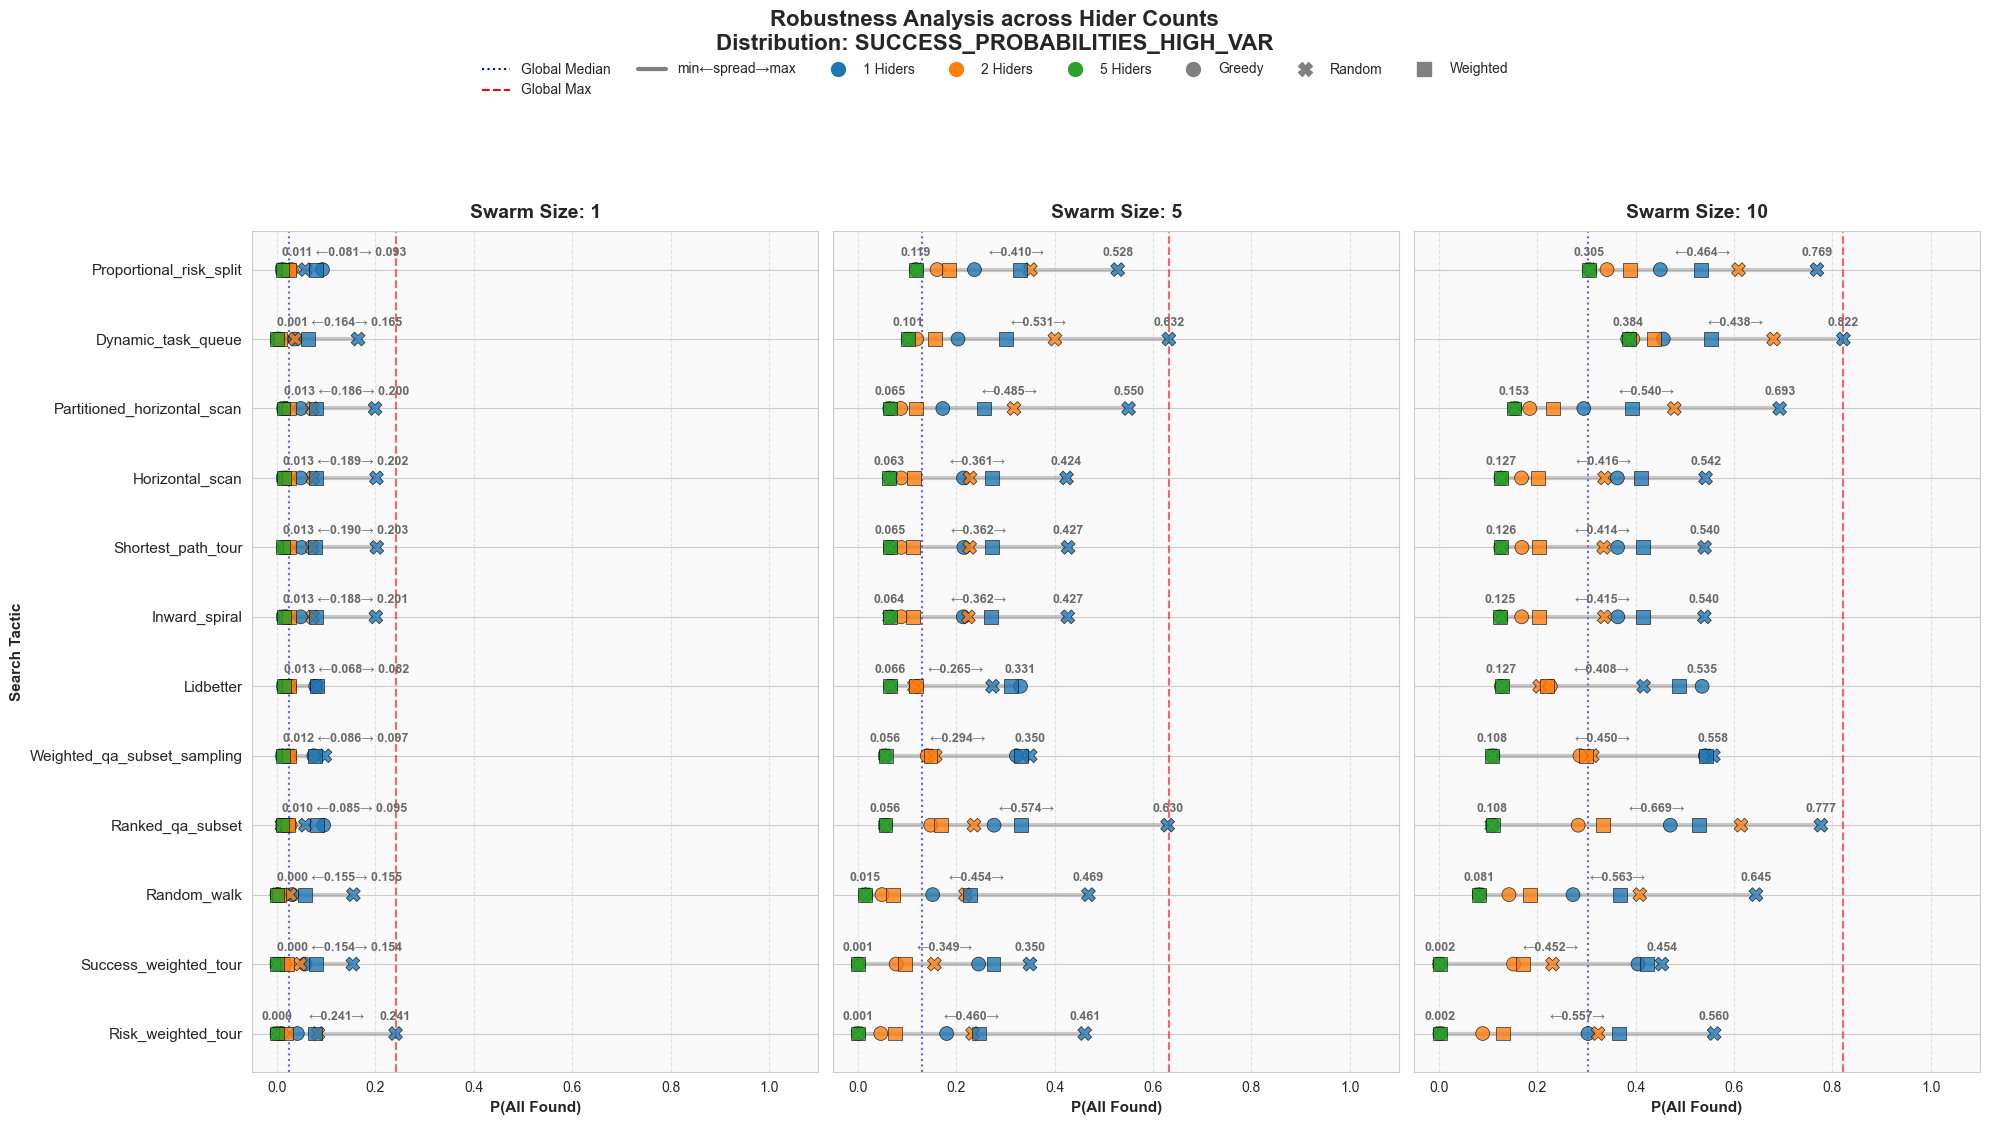

Generating plot for distribution: SUCCESS_PROBABILITIES_LOW_VAR...
Saved plot to: ..\plots\SUCCESS_PROBABILITIES_LOW_VAR\horizontal_H125_robustness_SUCCESS_PROBABILITIES_LOW_VAR.svg


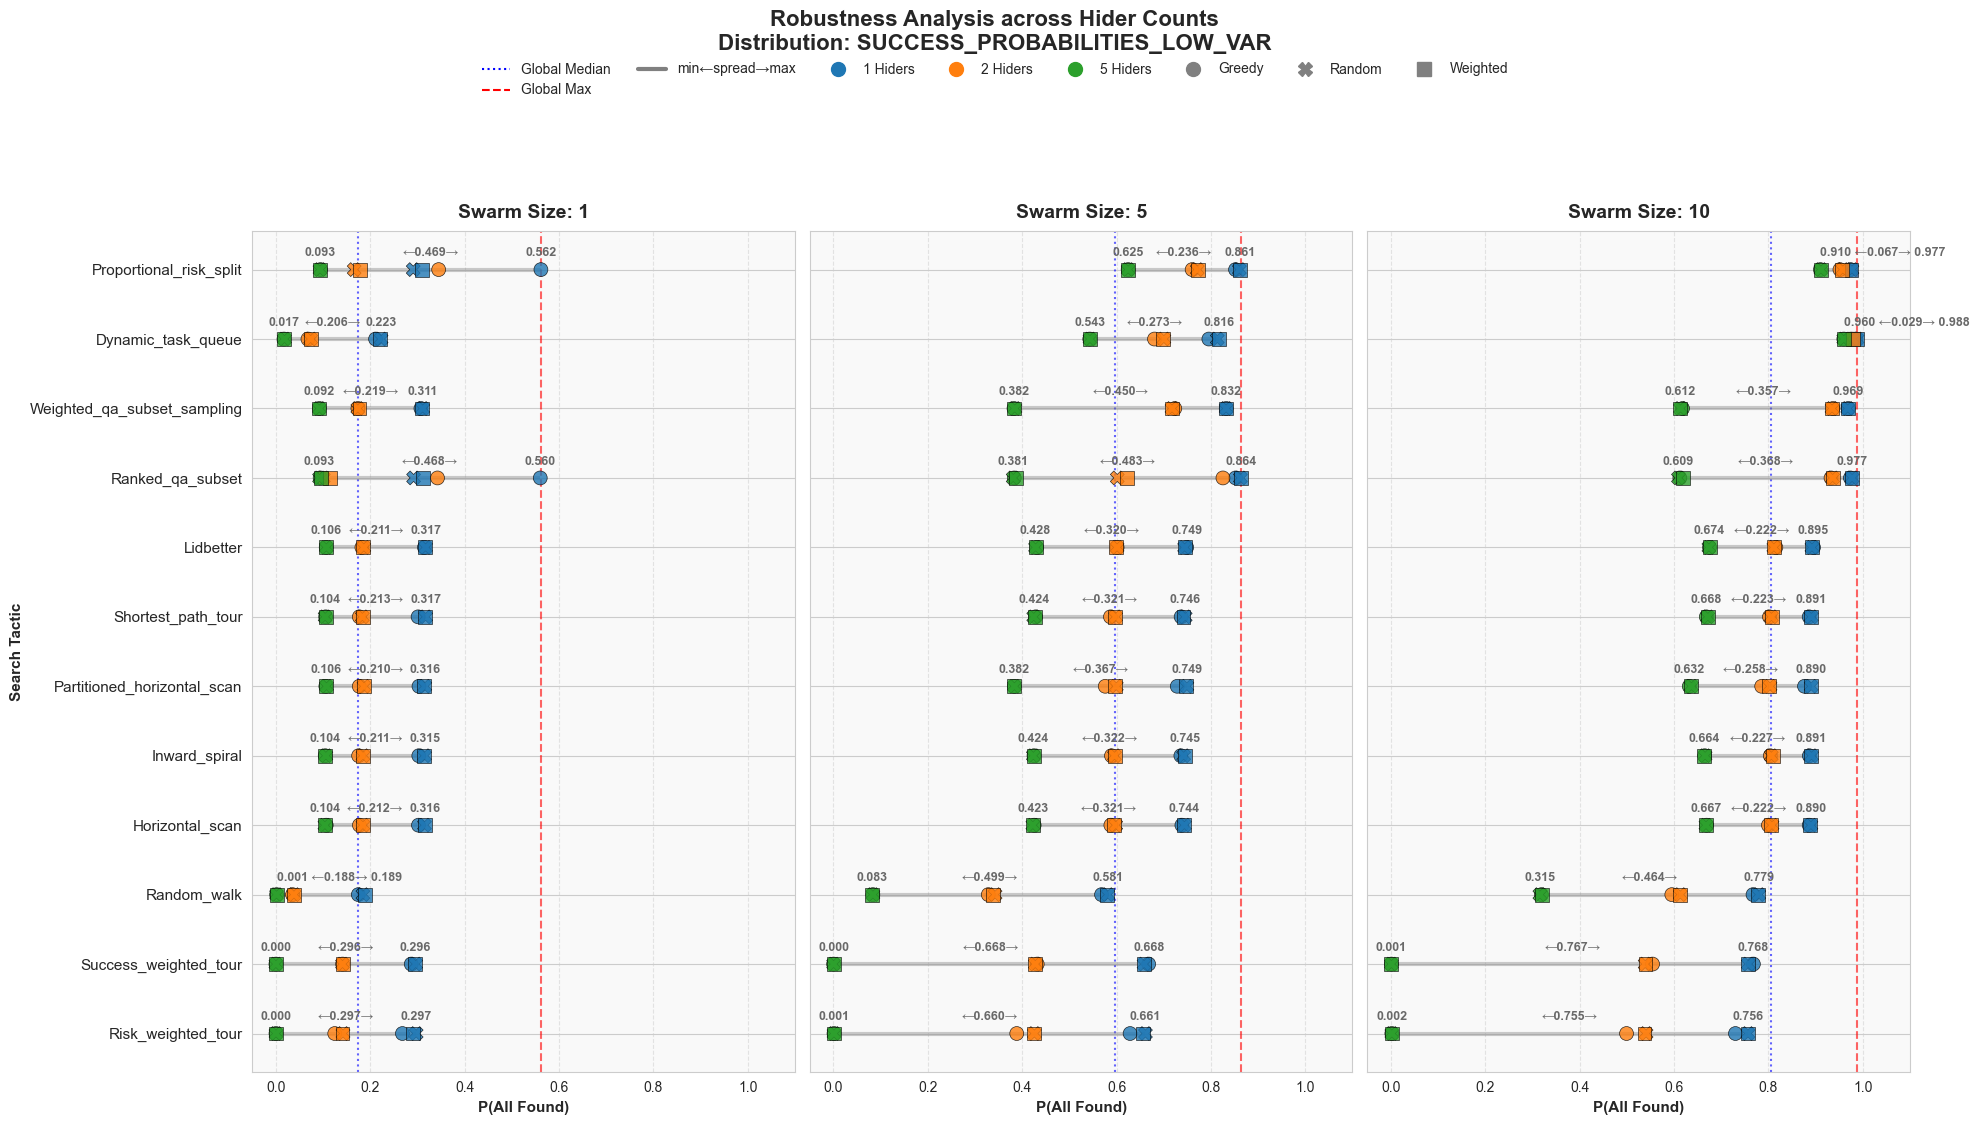

Generating plot for distribution: SUCCESS_PROBABILITIES_SKEWED...
Saved plot to: ..\plots\SUCCESS_PROBABILITIES_SKEWED\horizontal_H125_robustness_SUCCESS_PROBABILITIES_SKEWED.svg


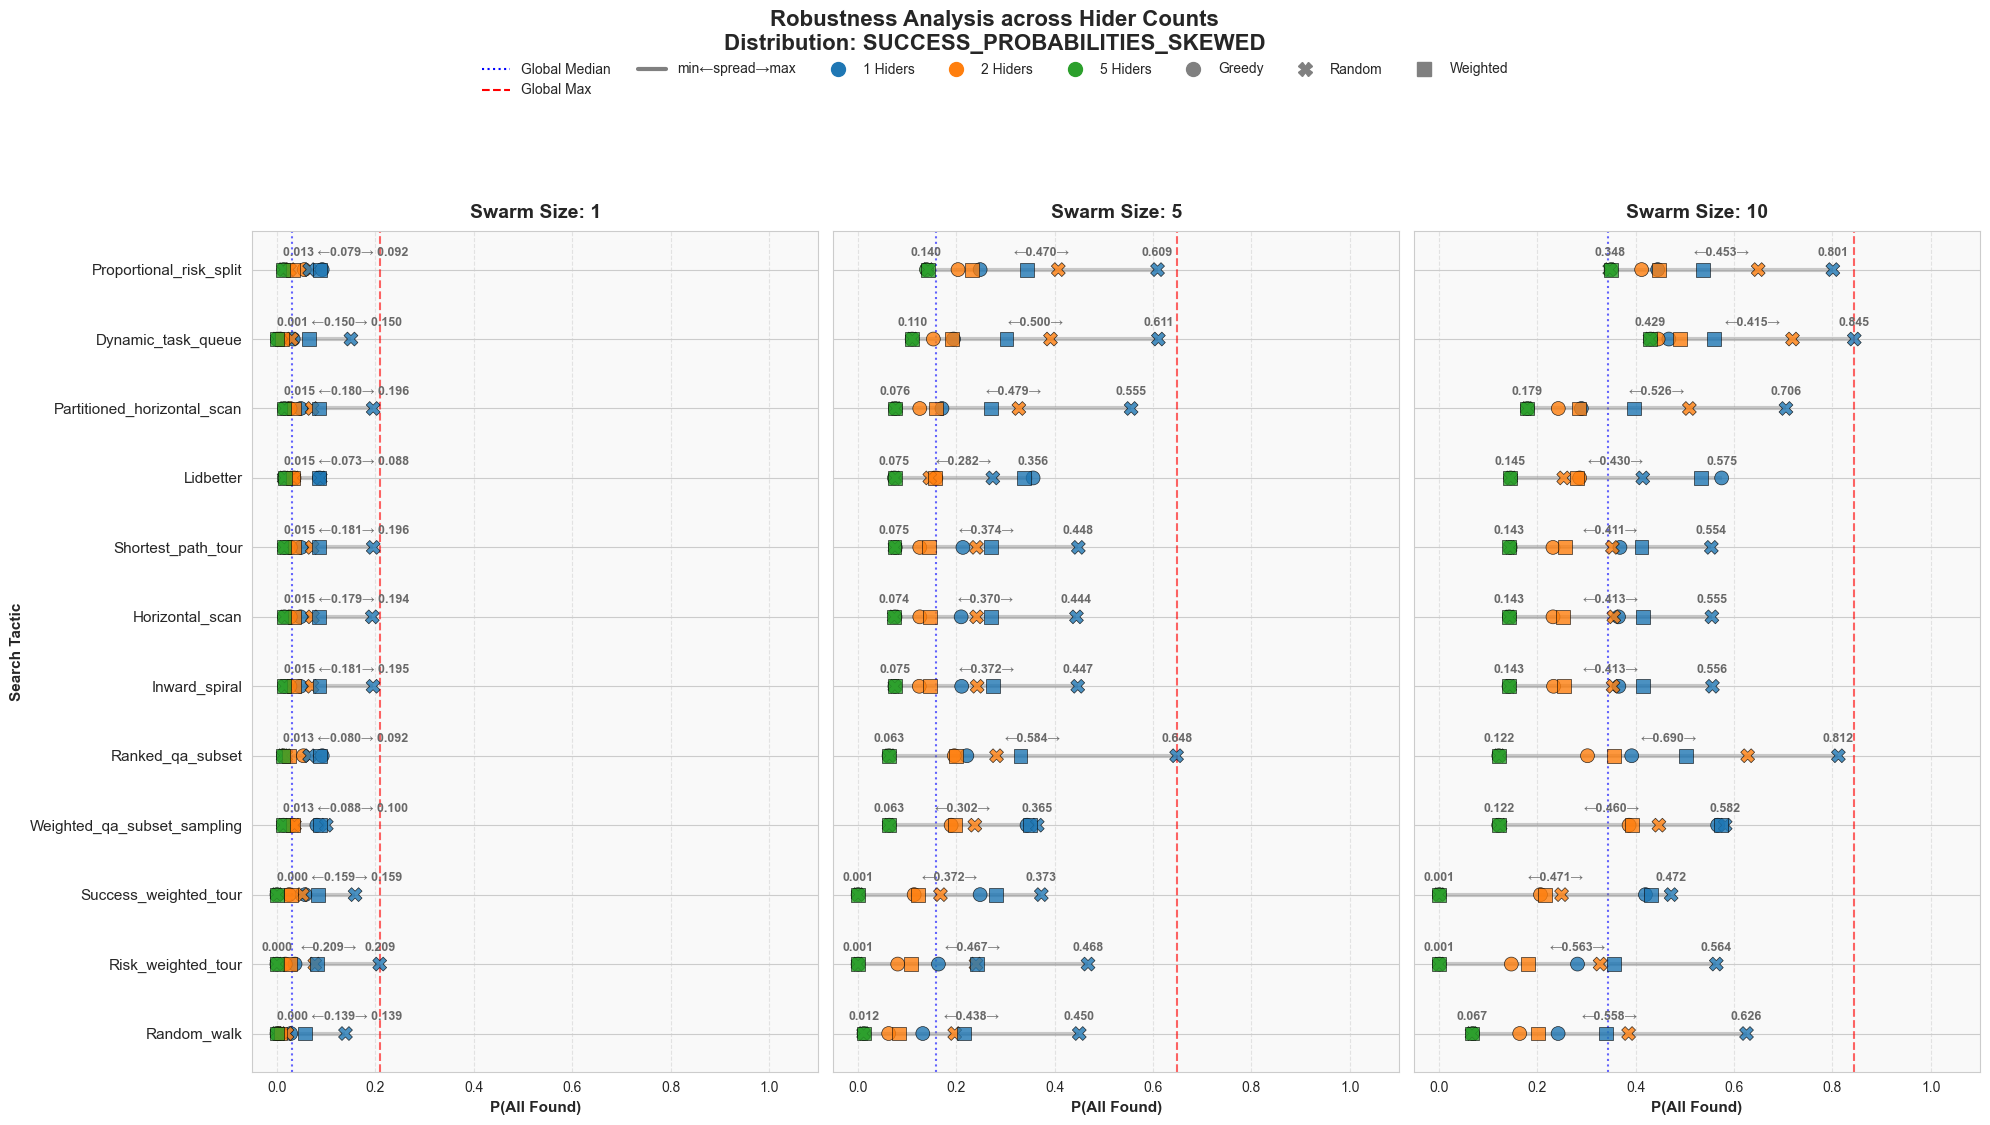

In [29]:

# ==========================================
#      CREATE DATAFRAME AND PLOT
# ==========================================

df_robustness = pd.DataFrame(all_data_rows)

if not df_robustness.empty:
    print(f"\nGenerated DataFrame with {len(df_robustness)} rows.")
    unique_dists = df_robustness['Distribution'].unique()

    for dist_name in unique_dists:
        print(f"Generating plot for distribution: {dist_name}...")
        plot_robustness_by_hiders(df_robustness, dist_name=dist_name, swarm_sizes=SWARM_SIZES)

else:
    print("DataFrame is empty. No data found matching the criteria.")

Starting Data Loading and Processing...
Loaded 960 rows for SUCCESS_PROBABILITIES_HIGH_VAR
Loaded 960 rows for SUCCESS_PROBABILITIES_LOW_VAR
Loaded 960 rows for SUCCESS_PROBABILITIES_SKEWED

Generated DataFrame with 1728 rows.
Generating plot for Hiders: 1...


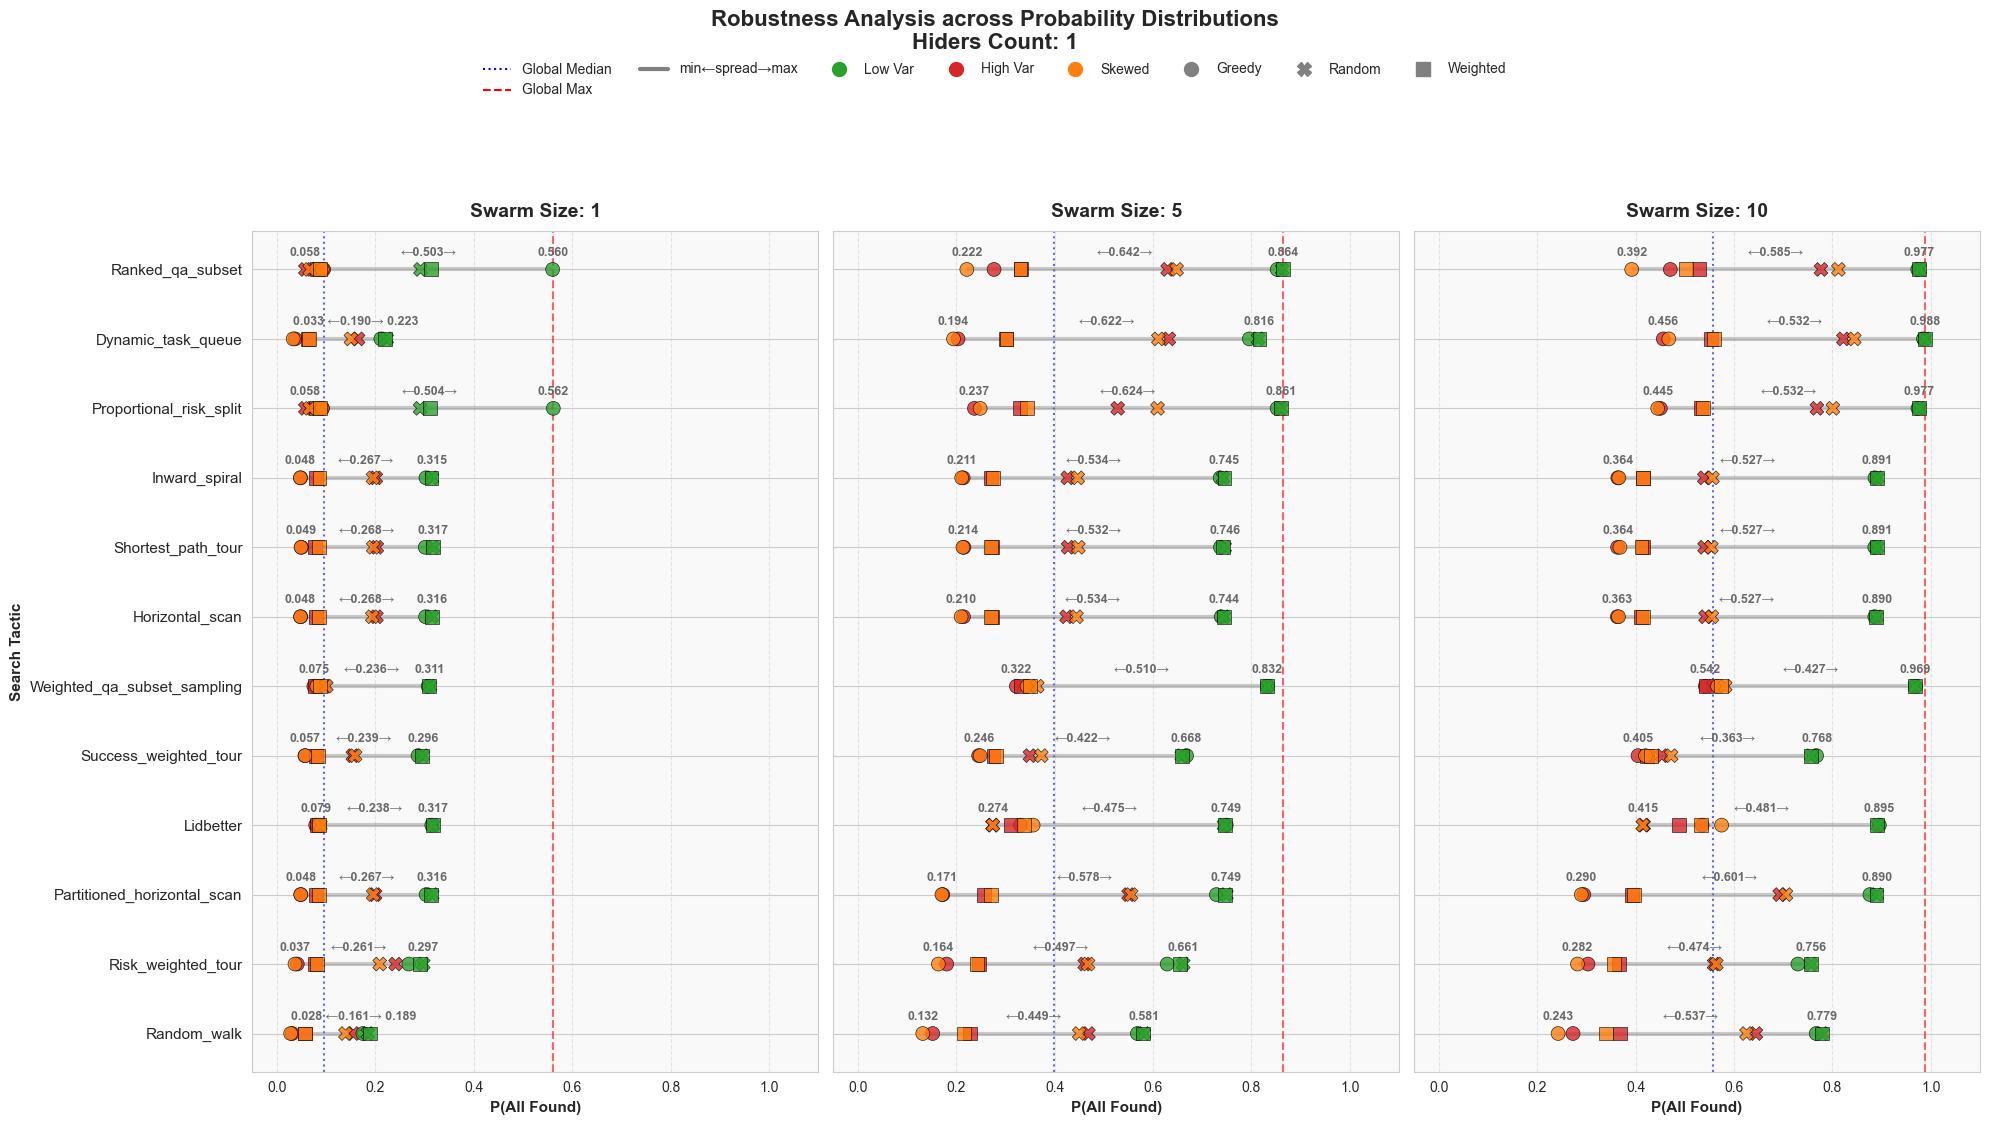

Generating plot for Hiders: 2...


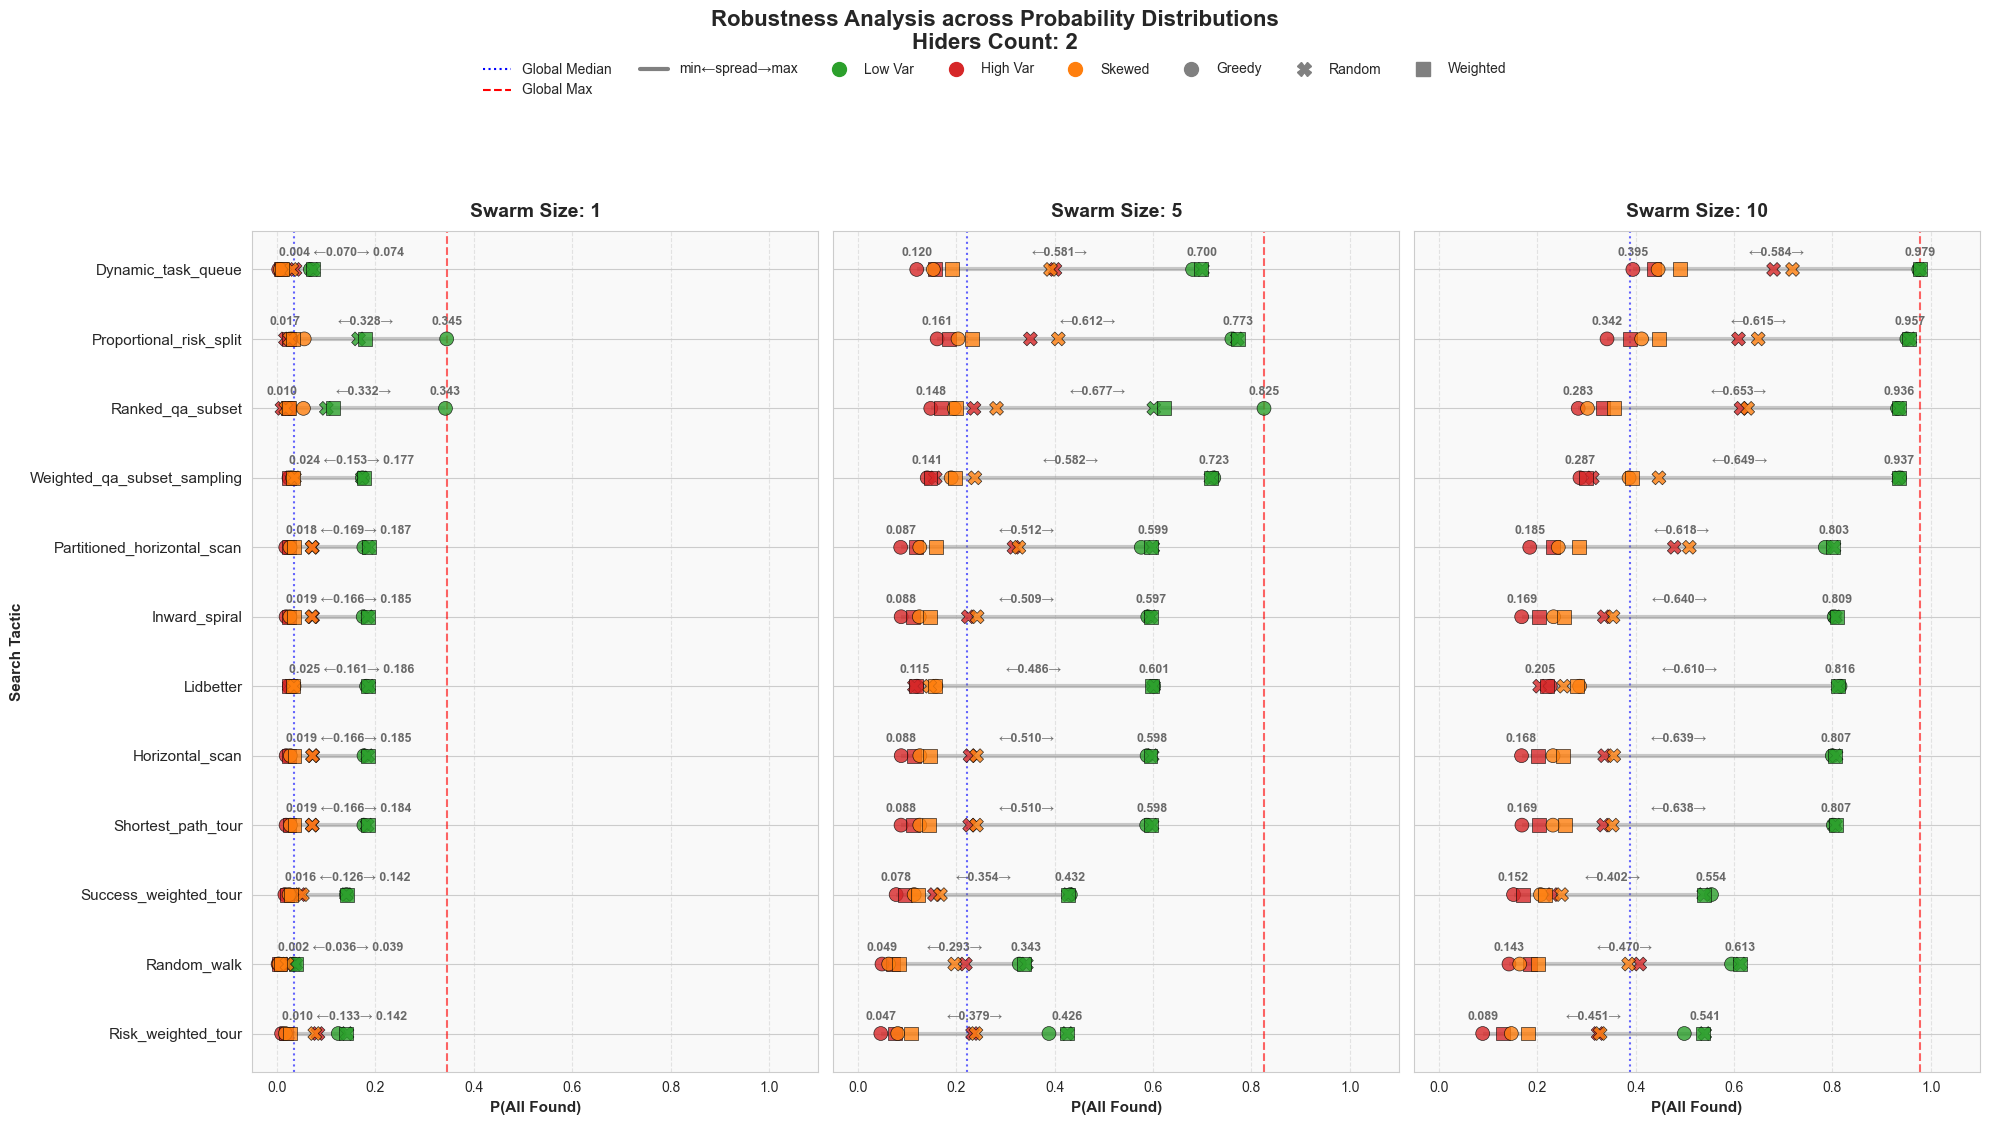

Generating plot for Hiders: 5...


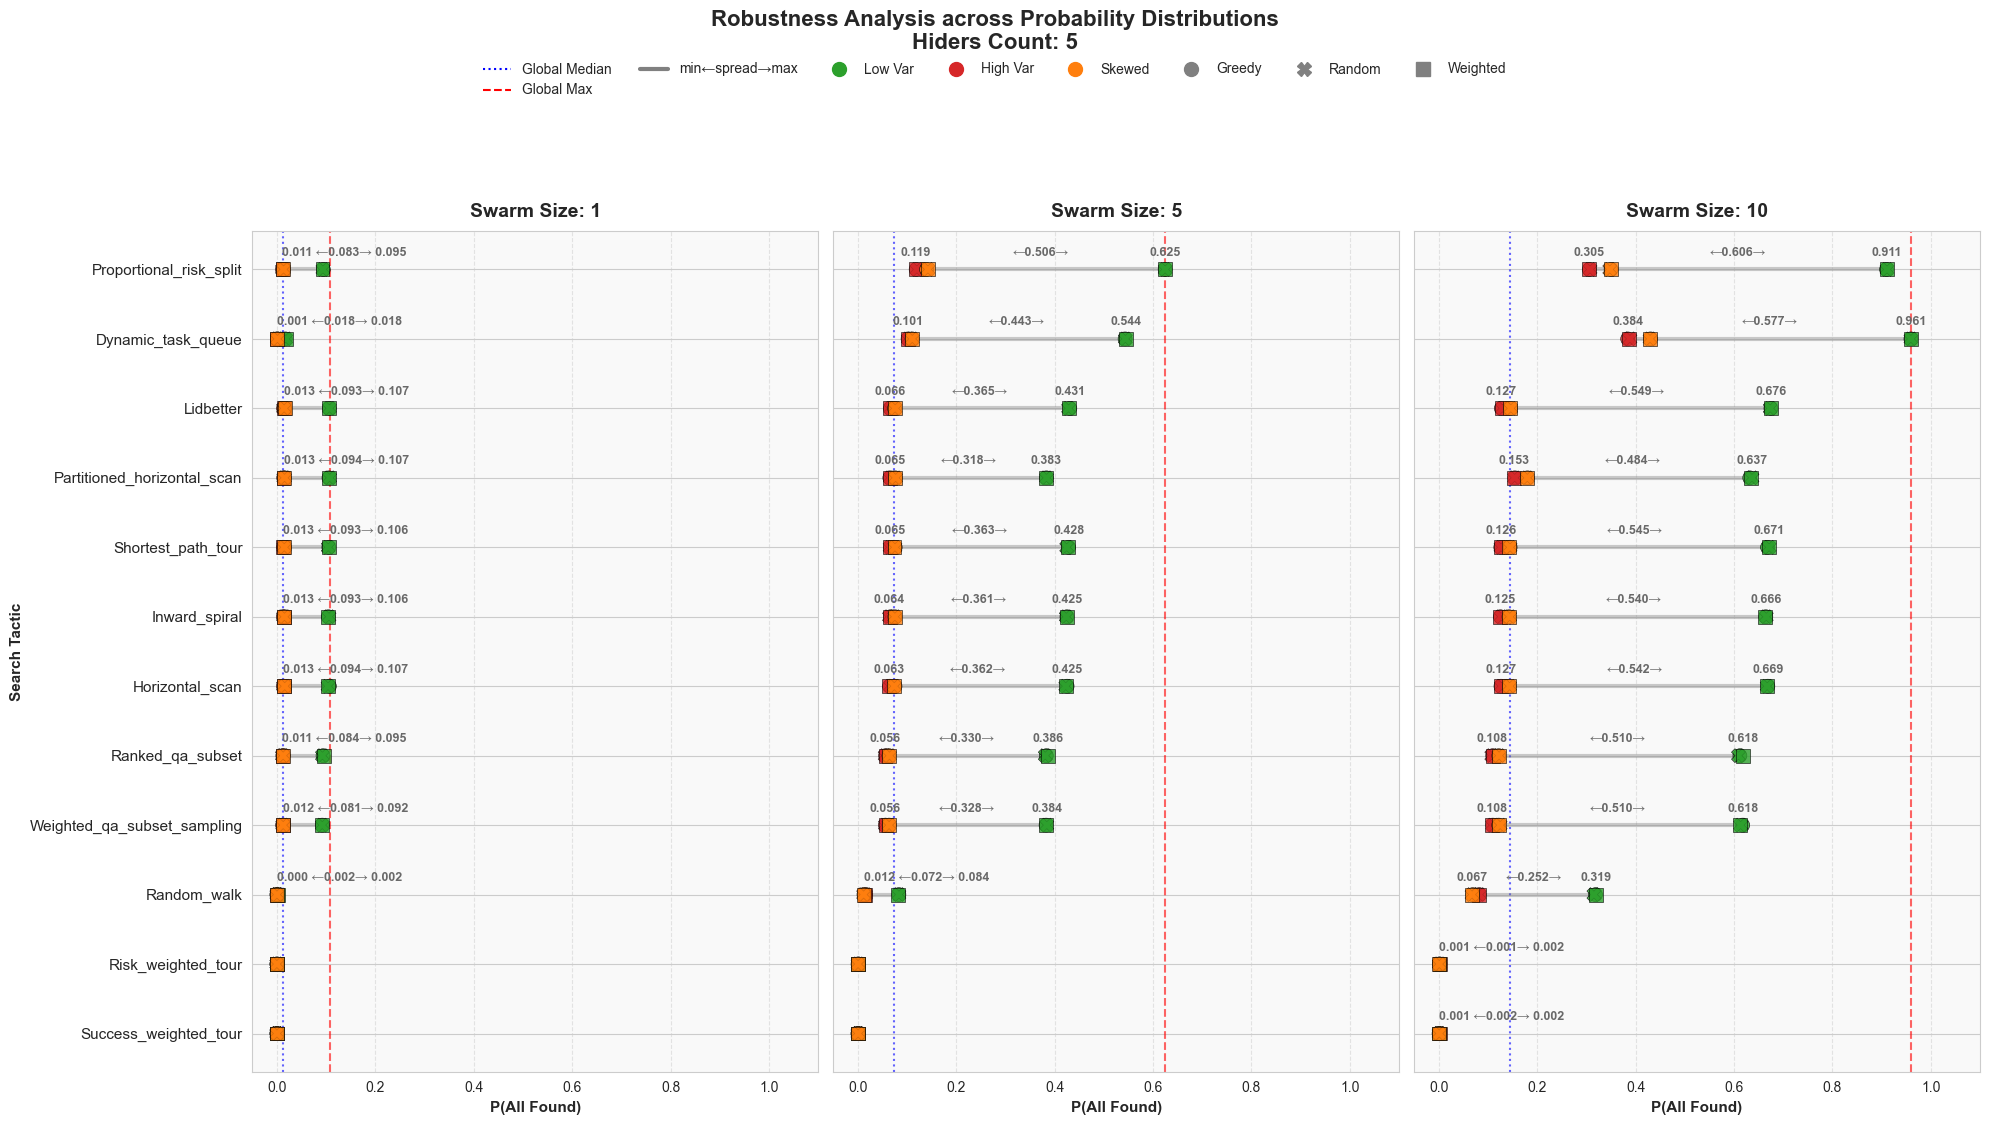

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import os

# ==========================================
# 1. DATA EXTRACTION FUNCTION (Unchanged)
# ==========================================
def obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist):
    mask = (
        (df_all['hide_strategy'] == hiding_strategy) &
        (df_all['n_hiders'] == n_hiders) &
        (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
        (df_all['grid_width'] == FIXED_GRID_WIDTH) &
        (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
    )

    df_filtered = df_all[mask]

    if df_filtered.empty:
        return None

    results = {}

    for tactic_name in df_filtered['tactic'].unique():
        df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]
        df_tactic = df_tactic.sort_values(by='swarm_size')

        results[tactic_name] = {
            'swarm_sizes': df_tactic['swarm_size'].values,
            'P': df_tactic['all_found_mean'].values,
            'low': df_tactic['all_found_ci_lower'].values,
            'high': df_tactic['all_found_ci_upper'].values
        }

    sorted_results = sorted(
        results.items(),
        key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
        reverse=True
    )

    return sorted_results

# ==========================================
# 2. PLOTTING FUNCTION (Modified for Dist Hue)
# ==========================================
def plot_robustness_by_distribution(df, current_n_hiders, swarm_sizes=[1, 5, 10]):
    """
    Robustness Cleveland Dot Plot for a SINGLE Hider Count (e.g., H=1).
    Color (Hue) now represents the Probability Distribution.
    """

    # Filter data for requested swarm sizes AND the specific hider count
    df = df[(df['Swarm Size'].isin(swarm_sizes)) & (df['Hiders'] == current_n_hiders)]

    if df.empty:
        print(f"No data available for Hiders: {current_n_hiders}")
        return

    # --- DEFINE COLORS FOR DISTRIBUTIONS ---
    unique_dists = sorted(df['Distribution'].unique())

    # Specific color mapping for consistency
    palet_obj = create_palet(4)

    dist_colors = {
        'SUCCESS_PROBABILITIES_LOW_VAR': palet_obj[2],
        'SUCCESS_PROBABILITIES_HIGH_VAR': palet_obj[3],
        'SUCCESS_PROBABILITIES_SKEWED': palet_obj[1]
    }
    # Shorter labels for the legend
    dist_labels = {
        'SUCCESS_PROBABILITIES_LOW_VAR': 'Low Var',
        'SUCCESS_PROBABILITIES_HIGH_VAR': 'High Var',
        'SUCCESS_PROBABILITIES_SKEWED': 'Skewed'
    }

    strat_markers = {
        'greedy': 'o',
        'random': 'X',
        'weighted': 's'
    }

    # Sort Tactics by Global Median Score within this specific hider scenario
    if 'Score' not in df.columns:
        print("Error: 'Score' column missing")
        return

    tactic_order = df.groupby('Tactic')['Score'].median().sort_values(ascending=True).index.tolist()

    # Setup Figure
    num_sizes = len(swarm_sizes)
    fig, axes = plt.subplots(nrows=1, ncols=num_sizes, figsize=(20, 10), sharey=True)
    if num_sizes == 1: axes = [axes]

    # --- PLOTTING LOOP ---
    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]
        subset = df[df['Swarm Size'] == size]

        # Global Benchmarks for this panel
        global_median = subset['Score'].median()
        global_max = subset['Score'].max()

        # Grid and Background
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        ax.set_facecolor('#f9f9f9')

        # --- 1. PLOT GLOBAL LINES ---
        ax.axvline(x=global_median, color='blue', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        ax.axvline(x=global_max, color='red', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

        # --- 2. DRAW SPREAD LINES AND LABELS ---
        for y_idx, tactic in enumerate(tactic_order):
            tactic_data = subset[subset['Tactic'] == tactic]
            if tactic_data.empty: continue
            min_score = tactic_data['Score'].min()
            max_score = tactic_data['Score'].max()
            spread = max_score - min_score
            midpoint = (min_score + max_score) / 2

            # Draw the line
            ax.hlines(y=y_idx, xmin=min_score, xmax=max_score,
                      color='gray', alpha=0.4, linewidth=3, zorder=1)


            overlap_threshold = 0.2

            if spread > 0.001:

                if spread < overlap_threshold:

                    combined_text = f"{min_score:.3f} ←{spread:.3f}→ {max_score:.3f}"

                    ax.text(x=min_score, y=y_idx + 0.15, s=combined_text,
                            ha='left', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                else:
                    ax.text(x=midpoint, y=y_idx + 0.15, s=f"←{spread:.3f}→",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')

                    ax.text(x=min_score, y=y_idx + 0.15, s=f"{min_score:.3f}",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')


                    ax.text(x=max_score, y=y_idx + 0.15, s=f"{max_score:.3f}",
                            ha='center', va='bottom', fontsize=9,
                            color='dimgray', fontweight='bold')



        subset_copy = subset.copy()
        subset_copy['Tactic_Idx'] = subset_copy['Tactic'].apply(lambda x: tactic_order.index(x) if x in tactic_order else -1)

        sns.scatterplot(
            data=subset_copy,
            x='Score',
            y='Tactic_Idx',
            hue='Distribution',
            style='Hiding Strategy',
            palette=dist_colors,
            markers=strat_markers,
            s=100,
            alpha=0.8,
            edgecolor='k',
            linewidth=0.5,
            ax=ax,
            zorder=3,
            legend=False
        )

        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel("P(All Found)", fontsize=11, fontweight='bold')
        ax.set_xlim(-0.05, 1.1)

        if i == 0:
            ax.set_yticks(range(len(tactic_order)))
            ax.set_yticklabels(tactic_order, fontsize=11)
            ax.set_ylabel("Search Tactic", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.tick_params(left=False)

    # --- CUSTOM LEGEND ---
    median_handle = mlines.Line2D([], [], color='blue', linestyle=':', linewidth=1.5, label='Global Median')
    max_handle = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.5, label='Global Max')
    spread_handle = mlines.Line2D([], [], color='gray', linewidth=3, label='min←spread→max')

    # Dist Handles (Color)
    dist_handles = [
        mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                      markersize=10, label=dist_labels.get(d, d))
        for d, color in dist_colors.items() if d in df['Distribution'].unique()
    ]

    # Strategy Handles (Shape)
    shape_handles = [
        mlines.Line2D([], [], color='grey', marker=marker, linestyle='None',
                      markersize=10, label=key.capitalize())
        for key, marker in strat_markers.items() if key in df['Hiding Strategy'].unique()
    ]

    all_handles = [median_handle, max_handle, spread_handle] + dist_handles + shape_handles

    fig.legend(handles=all_handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 1.08),
               ncol=8,
               fontsize=10,
               frameon=False
              )

    plt.suptitle(f"Robustness Analysis across Probability Distributions\nHiders Count: {current_n_hiders}",
                 y=1.12, fontsize=16, fontweight='bold')

    plt.tight_layout()

    # Save logic
    save_path = os.path.join("..", "plots", "H_Robustness", f"robustness_H{current_n_hiders}_all_dists.svg")
    # Ensure directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# ==========================================
# 3. MAIN EXECUTION LOGIC
# ==========================================

all_data_rows = []

if 'RESULTS_DICT' not in locals():
    RESULTS_DICT = {}

print("Starting Data Loading and Processing...")
HIDERS_TO_PLOT = [1, 2, 5]

# Define the old names list for filtering (if not already defined globally)
to_plot_tacts_old = list(tactic_abbr_full.values())

# 1. LOAD ALL DATA INTO ONE DATAFRAME FIRST
for p_dist in probability_distributions:
    if p_dist == "SUCCESS_PROBABILITIES_INITIAL":
        continue

    try:
        file_path = get_file_name(p_dist, t="SUMMARY_FILENAME")
        df_all = pd.read_csv(file_path)

        # --- CHANGE 1: Filter using OLD names (as they appear in CSV) ---
        df_all = df_all[df_all['tactic'].isin(to_plot_tacts_old)]

        # --- CHANGE 2: Apply the rename map immediately ---
        df_all['tactic'] = df_all['tactic'].replace(rename_map)

        print(f"Loaded {len(df_all)} rows for {p_dist}")

        if p_dist not in RESULTS_DICT:
            RESULTS_DICT[p_dist] = {}

        for hiding_strategy in HIDING_STRATEGIES:
            for n_hiders in HIDERS_TO_PLOT:

                # Note: obtain_right_data_robuustness will now see the NEW names
                res = obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist)

                if res:
                    RESULTS_DICT[p_dist][hiding_strategy] = res

                    for tactic_name, metrics in res:
                        swarms = metrics['swarm_sizes']
                        scores = metrics['P']

                        for i, swarm_size in enumerate(swarms):
                            all_data_rows.append({
                                'Tactic': tactic_name, # This is now the NEW name
                                'Distribution': p_dist,
                                'Hiding Strategy': hiding_strategy,
                                'Hiders': n_hiders,
                                'Swarm Size': swarm_size,
                                'Score': scores[i]
                            })

    except Exception as e:
        print(f"Error processing {p_dist}: {e}")

# ==========================================
# 4. CREATE DATAFRAME AND PLOT LOOP
# ==========================================

df_robustness = pd.DataFrame(all_data_rows)

if not df_robustness.empty:
    print(f"\nGenerated DataFrame with {len(df_robustness)} rows.")

    # Get the unique Hider Counts found in the data (should be 1, 2, 5)
    available_hider_counts = sorted(df_robustness['Hiders'].unique())

    # --- LOOP OVER HIDERS (Instead of Distributions) ---
    for h_count in available_hider_counts:
        print(f"Generating plot for Hiders: {h_count}...")
        plot_robustness_by_distribution(df_robustness, current_n_hiders=h_count, swarm_sizes=SWARM_SIZES)

else:
    print("DataFrame is empty. No data found matching the criteria.")

Calculating "wins" across all scenarios...
Tie found in SUCCESS_PROBABILITIES_LOW_VAR | Hiders: 1 | Size: 5 -> ['divide_over_risks' 'traverse_ordered_qa']
Tie found in SUCCESS_PROBABILITIES_LOW_VAR | Hiders: 1 | Size: 1 -> ['lidbetter' 'together_traverse_best_permutation']
Tie found in SUCCESS_PROBABILITIES_LOW_VAR | Hiders: 5 | Size: 1 -> ['horizontal_scan_traversal' 'lidbetter']
Tie found in SUCCESS_PROBABILITIES_LOW_VAR | Hiders: 5 | Size: 1 -> ['lidbetter' 'partitioned_horizontal_scan_traversal']
Tie found in SUCCESS_PROBABILITIES_LOW_VAR | Hiders: 5 | Size: 1 -> ['lidbetter' 'partitioned_horizontal_scan_traversal'
 'together_traverse_best_permutation']
Tie found in SUCCESS_PROBABILITIES_HIGH_VAR | Hiders: 1 | Size: 1 -> ['lidbetter' 'traverse_ordered_qa']
Tie found in SUCCESS_PROBABILITIES_HIGH_VAR | Hiders: 5 | Size: 1 -> ['partitioned_horizontal_scan_traversal'
 'together_traverse_best_permutation']
Tie found in SUCCESS_PROBABILITIES_HIGH_VAR | Hiders: 5 | Size: 1 -> ['partition

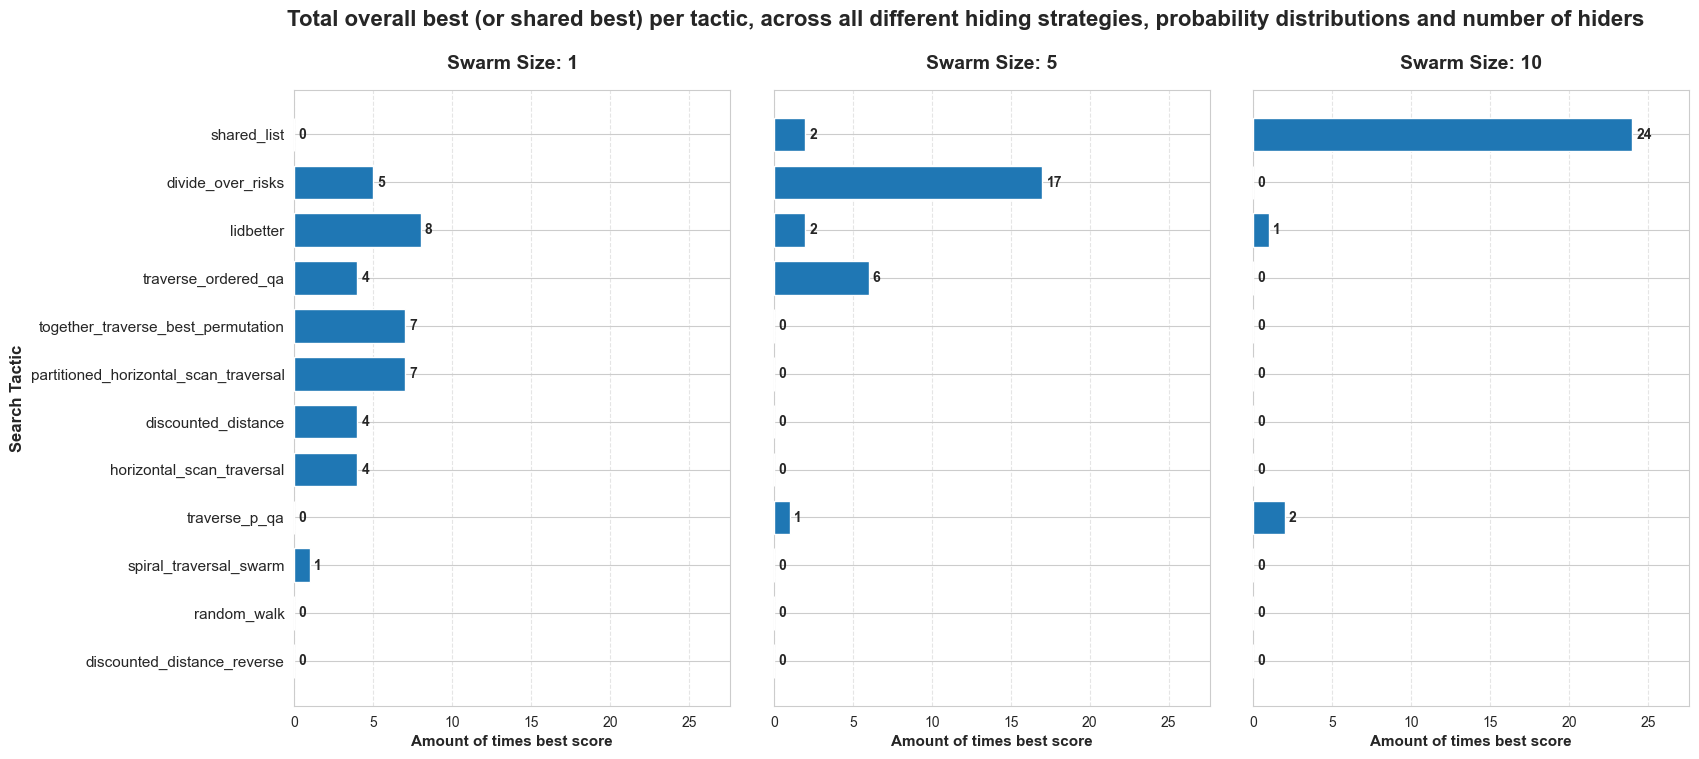

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_horizontal_total_wins(distributions, hider_counts, swarm_sizes, hiding_strategies, output_dir):
    """
    Calculates wins and plots a horizontal bar chart (Tactics on Y-axis).
    """

    win_data = []

    print("Calculating \"wins\" across all scenarios...")

    for p_dist in distributions:
        if p_dist == "SUCCESS_PROBABILITIES_INITIAL": continue

        try:
            file_path = f"../data/dataset/{p_dist}/sim_results_dataset.csv"
            if not os.path.exists(file_path):
                continue

            df_full = pd.read_csv(file_path)

            #Make sure to only take the tactics that are wanted
            df_full = df_full[df_full['tactic'].isin(to_plot_tacts)]

            # Iterate through scenarios
            for n_hiders in hider_counts:
                for hs in hiding_strategies:
                    for size in swarm_sizes:

                        mask = (
                            (df_full['n_hiders'] == n_hiders) &
                            (df_full['hide_strategy'] == hs) &
                            (df_full['swarm_size'] == size) &
                            (df_full['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
                            (df_full['grid_width'] == FIXED_GRID_WIDTH) &
                            (df_full['runs'] == FIXED_NUMBER_OF_RUNS)
                        )

                        subset = df_full[mask]
                        if subset.empty: continue

                        # --- FIX STARTS HERE ---

                        # 1. Get the raw max value
                        raw_max = subset['all_found_mean'].max()

                        # 2. Format the max value to a string (3 decimal places)
                        max_val_str = f"{raw_max:.3f}"

                        # 3. Create a boolean mask by converting the whole column to strings
                        #    and comparing against the max string. This captures ties.
                        is_winner = subset['all_found_mean'].apply(lambda x: f"{x:.3f}") == max_val_str

                        # 4. Filter the subset using this mask
                        winners = subset[is_winner]['tactic'].unique()

                        # --- FIX ENDS HERE ---

                        # Debug print to see if ties are being caught now
                        if len(winners) > 1:
                            print(f"Tie found in {p_dist} | Hiders: {n_hiders} | Size: {size} -> {winners}")

                        for winner in winners:
                            win_data.append({
                                'Tactic': winner,
                                'Swarm Size': size,
                                'Win': 1
                            })

        except Exception as e:
            print(f"Error processing {p_dist}: {e}")

    df_wins = pd.DataFrame(win_data)

    if df_wins.empty:
        print("No wins recorded.")
        return

    # 2. AGGREGATION & SORTING

    df_grouped = df_wins.groupby(['Tactic', 'Swarm Size'])['Win'].sum().reset_index()
    all_tactics_series = pd.Series(0, index=to_plot_tacts, name='Win')

    # 2. Update with actual wins from df_grouped
    actual_wins = df_grouped.groupby('Tactic')['Win'].sum()
    total_wins_all_tactics = all_tactics_series.add(actual_wins, fill_value=0)

    # 3. Sort to determine order
    global_totals = total_wins_all_tactics.sort_values(ascending=True)
    tactic_order = global_totals.index.tolist()

    # 3. PLOTTING

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 8), sharey=True)
    plt.subplots_adjust(wspace=0.1)

    palet_obj = create_palet(1)

    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]

        # Filter for this swarm size
        subset = df_grouped[df_grouped['Swarm Size'] == size]

        # Reindex against the global order to ensure missing tactics still appear (as 0 or empty)
        # to keep the y-axis aligned, or just plot what exists.
        # Here we map the subset to the global order:
        subset = subset.set_index('Tactic').reindex(tactic_order).fillna(0).reset_index()

        # Create Horizontal Bar Plot
        bars = ax.barh(subset['Tactic'], subset['Win'], color=palet_obj[0], height=0.7, zorder=3)

        # Add Count Labels to the end of bars
        ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold')

        # Formatting
        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold', pad=15)
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        ax.set_xlabel("Amount of times best score", fontsize=11, fontweight='bold')

        global_max_win = df_grouped['Win'].max()
        ax.set_xlim(0, global_max_win * 1.15)

        if i == 0:
            ax.set_ylabel("Search Tactic", fontsize=12, fontweight='bold')
            ax.tick_params(axis='y', labelsize=11)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', left=False)

    fig.suptitle("Total overall best (or shared best) per tactic, across all different hiding strategies, probability distributions and number of hiders ", y=0.98, fontsize=16, fontweight='bold')

    # Save
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, "horizontal_wins_aggregated.svg")
    #  plt.savefig(save_path, bbox_inches='tight')
    print(f"Plot saved to {save_path}")
    plt.show()

# ==========================================
# EXECUTE
# ==========================================

plot_horizontal_total_wins(
    distributions=['SUCCESS_PROBABILITIES_LOW_VAR', 'SUCCESS_PROBABILITIES_HIGH_VAR', 'SUCCESS_PROBABILITIES_SKEWED'],
    hider_counts=[1, 2, 5],
    swarm_sizes=[1, 5, 10],
    hiding_strategies=['greedy', 'random', 'weighted'],
    output_dir=os.path.join("..", "plots", "Aggregated_Wins")
)

Calculating "wins" across all scenarios...
Plot saved to ..\plots\Aggregated_Wins\horizontal_wins_stacked.svg


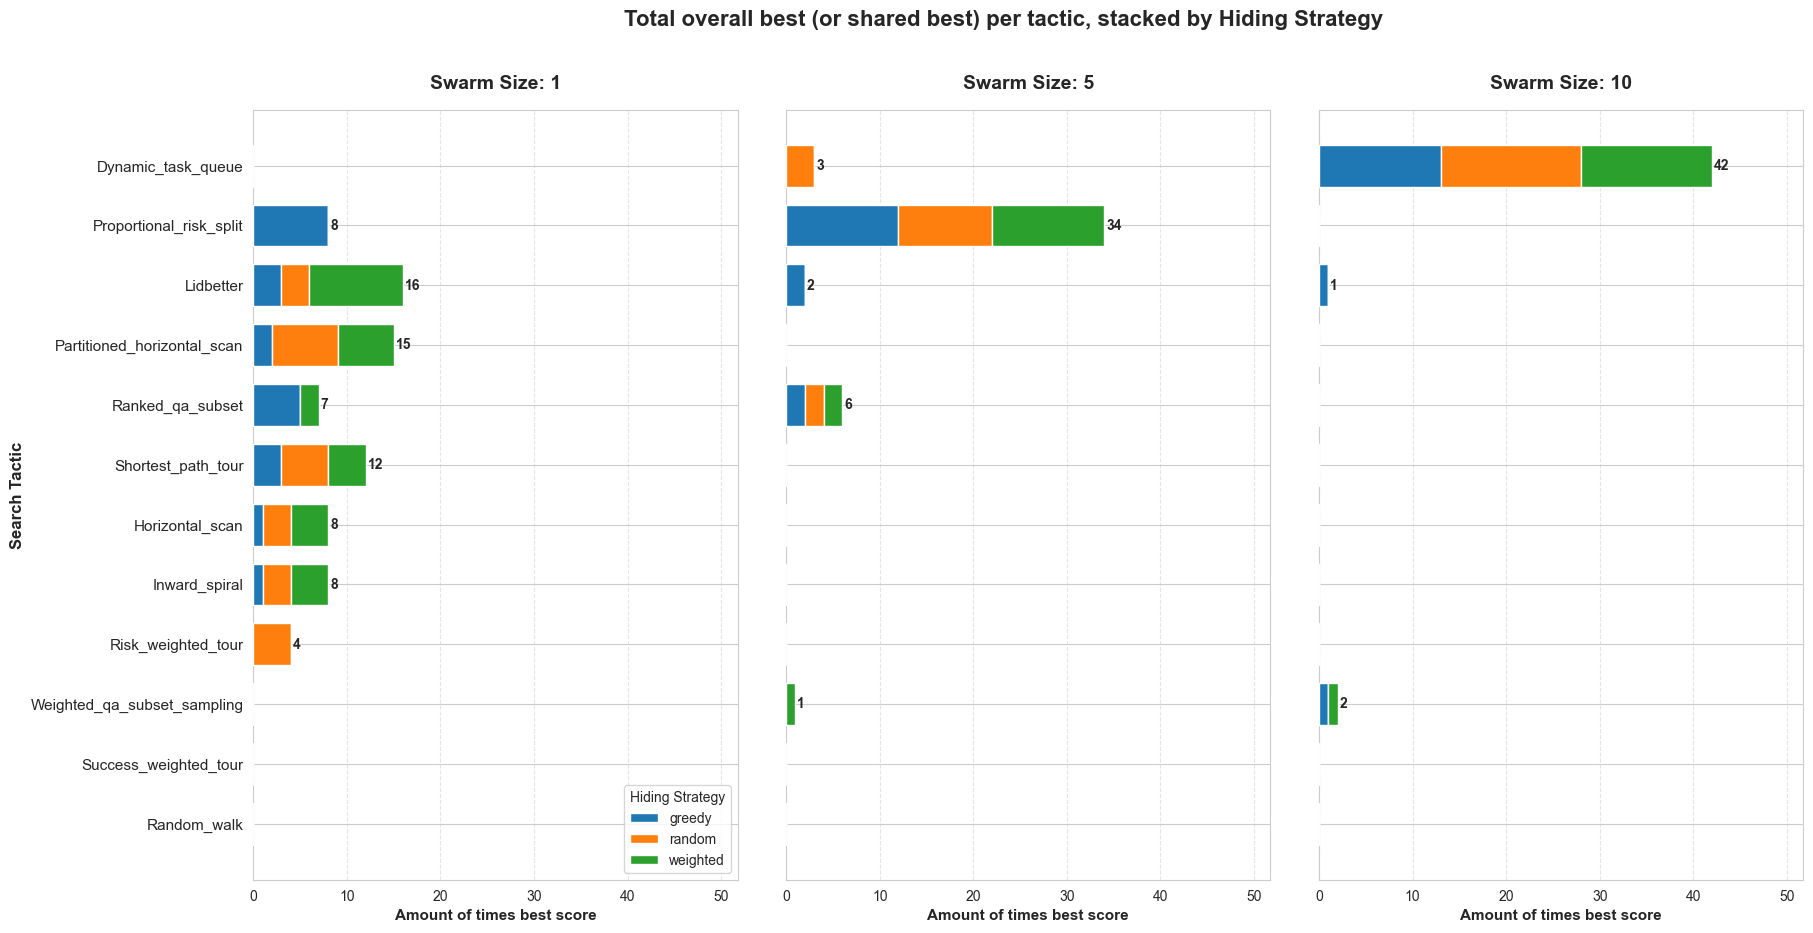

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_horizontal_total_wins_stacked(distributions, hider_counts, swarm_sizes, hiding_strategies, output_dir):
    """
    Calculates wins and plots a STACKED horizontal bar chart to show contribution
    of hiding strategies (Greedy, Random, Weighted).
    Ensures tactics with 0 wins are still shown.
    """

    win_data = []

    print("Calculating \"wins\" across all scenarios...")

    palet_obj = create_palet(3)
    strategy_colors = {
        'greedy': palet_obj[0],
        'random': palet_obj[1],
        'weighted': palet_obj[2]
    }
    stack_order = ['greedy', 'random', 'weighted']

    # --- 1. DEFINE MASTER LIST OF NEW NAMES ---
    # We need the list of NEW names to ensure 0-win tactics appear
    # This assumes 'to_plot_tacts_old' and 'rename_map' are defined globally as per previous steps
    full_tactic_list_new = [rename_map.get(t, t) for t in to_plot_tacts_old]

    for p_dist in distributions:
        if p_dist == "SUCCESS_PROBABILITIES_INITIAL": continue

        try:
            file_path = f"../data/dataset/{p_dist}/sim_results_dataset.csv"
            if not os.path.exists(file_path):
                continue

            df_full = pd.read_csv(file_path)

            if 'to_plot_tacts' in globals():
                df_full = df_full[df_full['tactic'].isin(to_plot_tacts_old)]

            # Rename to NEW names
            df_full['tactic'] = df_full['tactic'].replace(rename_map)

            for n_hiders in hider_counts:
                for hs in hiding_strategies:
                    for size in swarm_sizes:

                        mask = (
                            (df_full['n_hiders'] == n_hiders) &
                            (df_full['hide_strategy'] == hs) &
                            (df_full['swarm_size'] == size) &
                            (df_full['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
                            (df_full['grid_width'] == FIXED_GRID_WIDTH) &
                            (df_full['runs'] == FIXED_NUMBER_OF_RUNS)
                        )

                        subset = df_full[mask]
                        if subset.empty: continue

                        raw_max = subset['all_found_mean'].max()
                        max_val_str = f"{raw_max:.3f}"
                        is_winner = subset['all_found_mean'].apply(lambda x: f"{x:.3f}") == max_val_str
                        winners = subset[is_winner]['tactic'].unique()

                        for winner in winners:
                            win_data.append({
                                'Tactic': winner,
                                'Swarm Size': size,
                                'Hiding Strategy': hs,
                                'Win': 1
                            })

        except Exception as e:
            print(f"Error processing {p_dist}: {e}")

    df_wins = pd.DataFrame(win_data)

    # Note: removing the "if df_wins.empty" check or modifying it to handle empty case gracefully
    # is safer, but for now assuming at least one win exists somewhere.

    # 2. AGGREGATION & SORTING (FIXED)

    if not df_wins.empty:
        df_grouped = df_wins.groupby(['Tactic', 'Swarm Size', 'Hiding Strategy'])['Win'].sum().reset_index()
        # Calculate actual total wins per tactic
        actual_totals = df_grouped.groupby('Tactic')['Win'].sum()
    else:
        df_grouped = pd.DataFrame(columns=['Tactic', 'Swarm Size', 'Hiding Strategy', 'Win'])
        actual_totals = pd.Series(dtype=float)

    # --- FIX: MERGE WITH FULL LIST ---
    # Create a Series of 0s for ALL tactics (using new names)
    all_tactics_series = pd.Series(0, index=full_tactic_list_new, name='Win')

    # Add actual wins to the zero-series. fill_value=0 keeps the 0s where no wins exist.
    global_totals = all_tactics_series.add(actual_totals, fill_value=0).sort_values(ascending=True)

    tactic_order = global_totals.index.tolist()

    # 3. PLOTTING

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10), sharey=True)
    plt.subplots_adjust(wspace=0.1)

    global_max_win = global_totals.max()
    # Handle case where max win is 0 to avoid plot scaling errors
    if global_max_win == 0: global_max_win = 1

    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]

        subset = df_grouped[df_grouped['Swarm Size'] == size]

        if not subset.empty:
            pivot_df = subset.pivot_table(index='Tactic', columns='Hiding Strategy', values='Win', aggfunc='sum')
        else:
            # Create empty DataFrame if no wins for this swarm size
            pivot_df = pd.DataFrame()

        # Reindex ensures ALL tactics appear, even if rows are all NaN (which we fill with 0)
        pivot_df = pivot_df.reindex(tactic_order).fillna(0)

        for strat in stack_order:
            if strat not in pivot_df.columns:
                pivot_df[strat] = 0

        left_offset = np.zeros(len(pivot_df))

        for strat in stack_order:
            values = pivot_df[strat].values
            bars = ax.barh(
                pivot_df.index,
                values,
                left=left_offset,
                color=strategy_colors.get(strat, 'grey'),
                label=strat,
                height=0.7,
                zorder=3
            )
            left_offset += values

        row_totals = pivot_df.sum(axis=1)

        for idx, val in enumerate(row_totals):
            if val > 0:
                ax.text(val + 0.2, idx, str(int(val)), va='center', fontsize=10, fontweight='bold')

        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold', pad=15)
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        ax.set_xlabel("Amount of times best score", fontsize=11, fontweight='bold')
        ax.set_xlim(0, global_max_win * 1.15)

        if i == 0:
            ax.set_ylabel("Search Tactic", fontsize=12, fontweight='bold')
            ax.tick_params(axis='y', labelsize=11)
            ax.legend(title="Hiding Strategy", loc="lower right")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', left=False)

    fig.suptitle("Total overall best (or shared best) per tactic, stacked by Hiding Strategy", y=0.98, fontsize=16, fontweight='bold')

    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, "horizontal_wins_stacked.svg")
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Plot saved to {save_path}")
    plt.show()
# ==========================================
# EXECUTE
# ==========================================

plot_horizontal_total_wins_stacked(
    distributions=['SUCCESS_PROBABILITIES_LOW_VAR', 'SUCCESS_PROBABILITIES_HIGH_VAR', 'SUCCESS_PROBABILITIES_SKEWED'],
    hider_counts=[1, 2,3,4, 5],
    swarm_sizes=[1, 5, 10],
    hiding_strategies=['greedy', 'random', 'weighted'],
    output_dir=os.path.join("..", "plots", "Aggregated_Wins")
)

Loading data for Robustness Analysis (Hiders=1)...
Computed Maximin scores for Swarm Sizes: [ 1  2  3  4  5  6  7  8  9 10]
Plot saved to ..\plots\Turnaround_Analysis_H1.svg


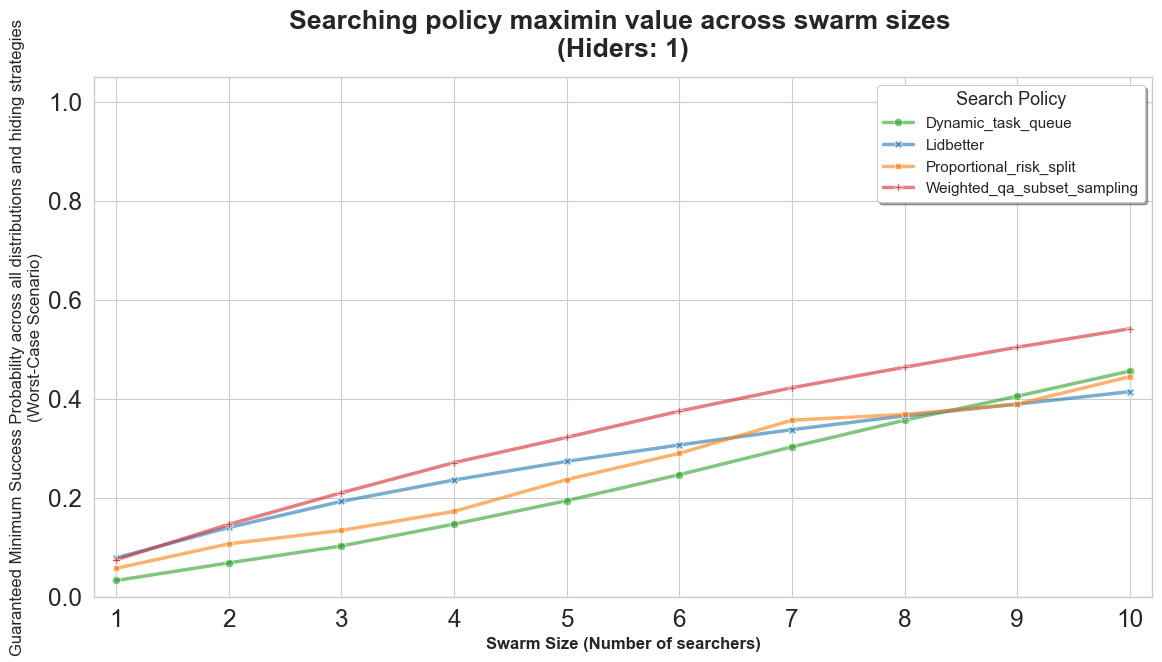

Loading data for Robustness Analysis (Hiders=2)...
Computed Maximin scores for Swarm Sizes: [ 1  2  3  4  5  6  7  8  9 10]
Plot saved to ..\plots\Turnaround_Analysis_H2.svg


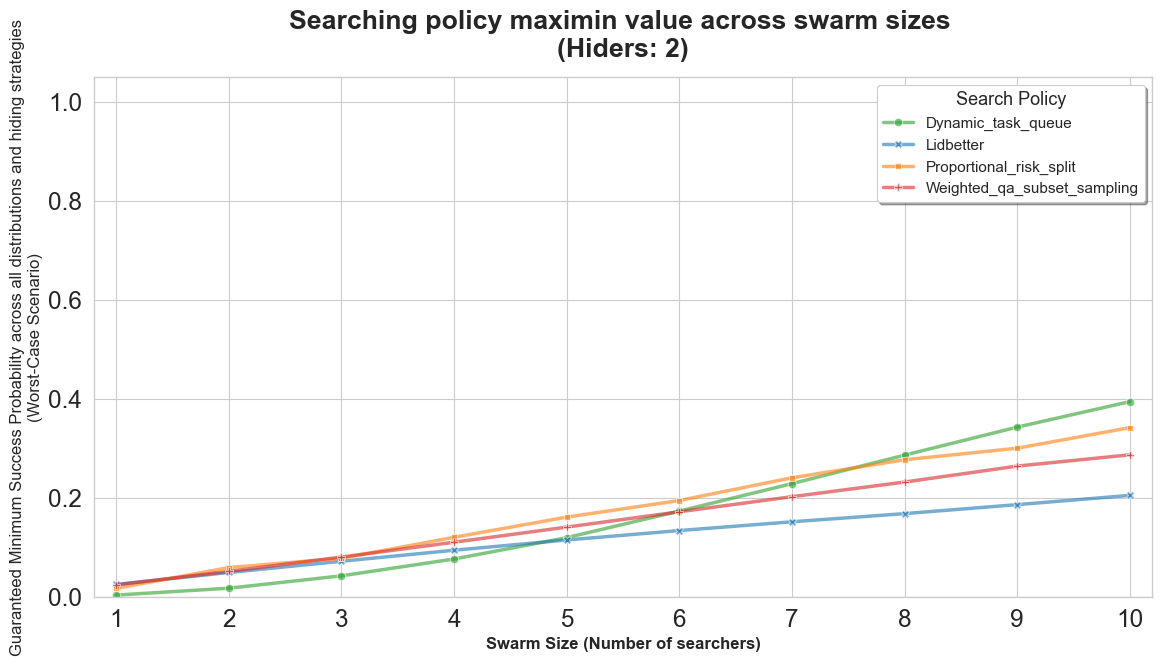

Loading data for Robustness Analysis (Hiders=3)...
Computed Maximin scores for Swarm Sizes: [ 1  2  3  4  5  6  7  8  9 10]
Plot saved to ..\plots\Turnaround_Analysis_H3.svg


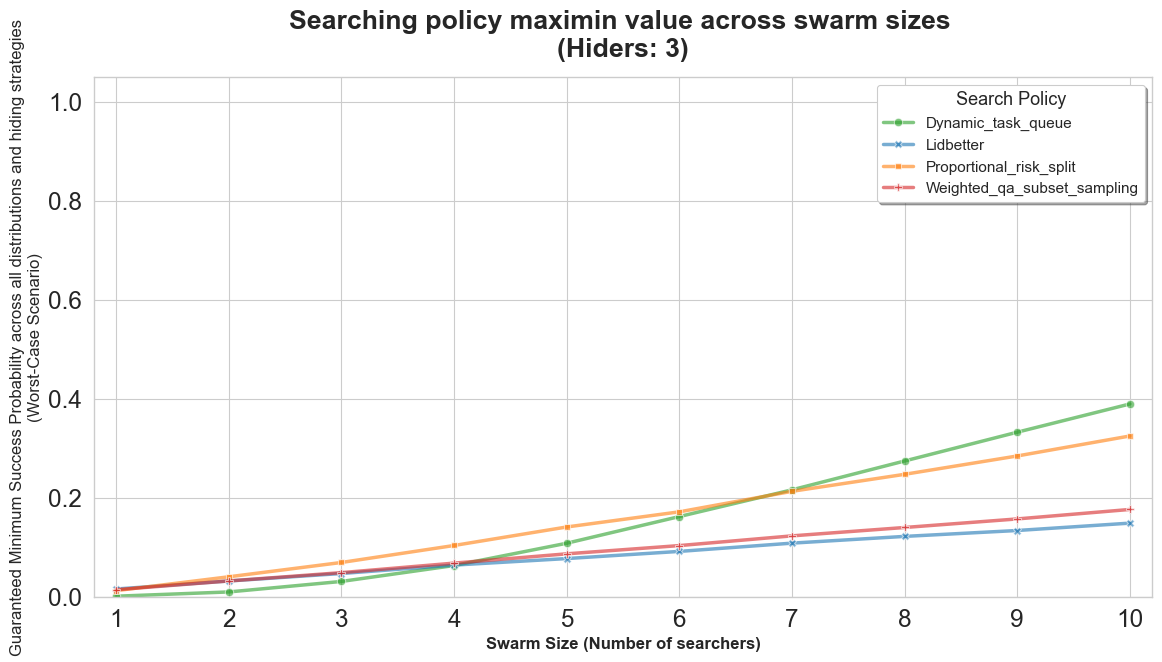

Loading data for Robustness Analysis (Hiders=4)...
Computed Maximin scores for Swarm Sizes: [ 1  2  3  4  5  6  7  8  9 10]
Plot saved to ..\plots\Turnaround_Analysis_H4.svg


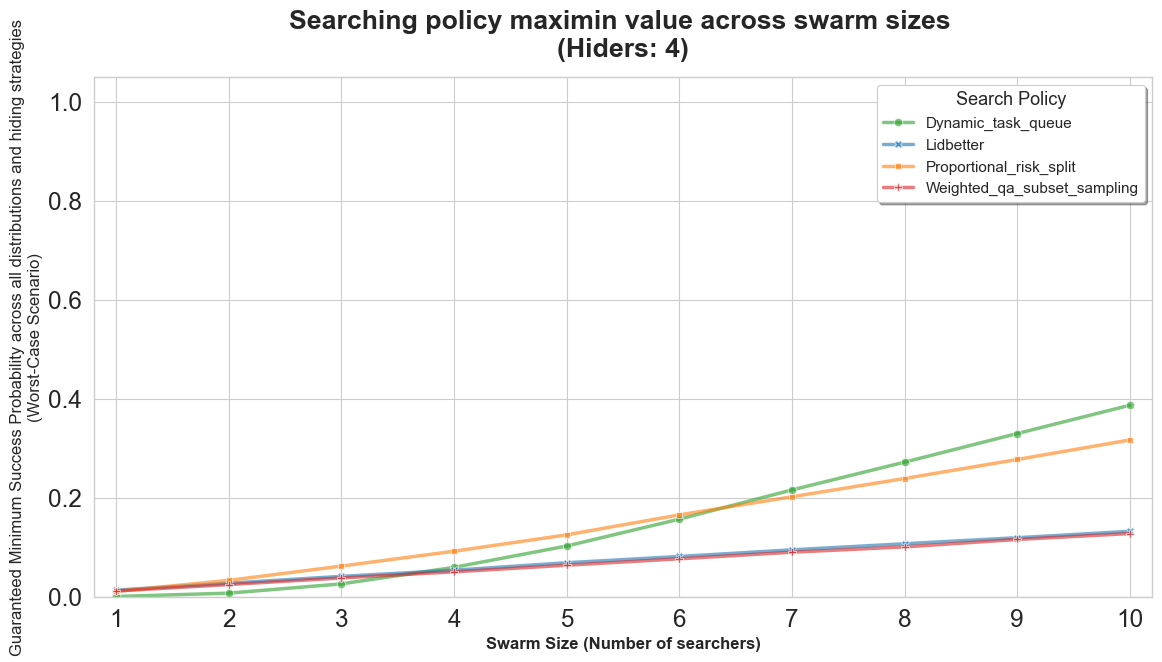

Loading data for Robustness Analysis (Hiders=5)...
Computed Maximin scores for Swarm Sizes: [ 1  2  3  4  5  6  7  8  9 10]
Plot saved to ..\plots\Turnaround_Analysis_H5.svg


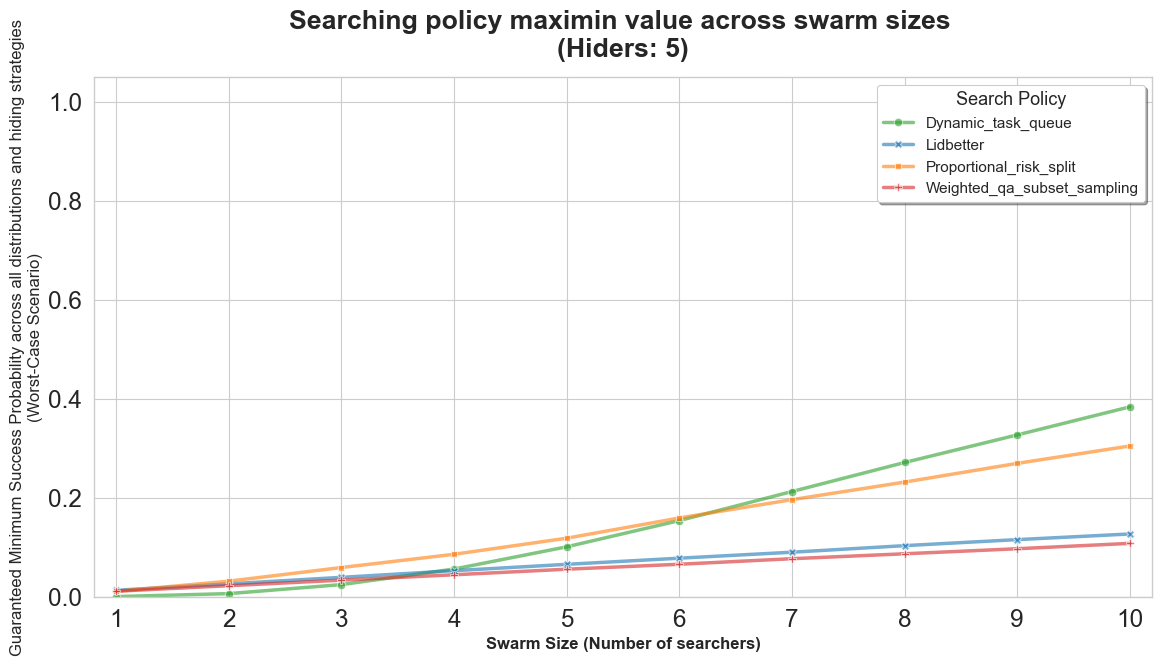

In [76]:
TARGET_TACTICS = [
    "Lidbetter",
    "Proportional_risk_split",
    "Dynamic_task_queue",
    "Weighted_qa_subset_sampling"
]

palet_obj = create_palet(4)

# Distributions to include in the "Worst Case" calculation
DISTS_TO_INCLUDE = [
    'SUCCESS_PROBABILITIES_LOW_VAR',
    'SUCCESS_PROBABILITIES_HIGH_VAR',
    'SUCCESS_PROBABILITIES_SKEWED'
]


ANALYSIS_HIDERS_COUNT = 5
for i in range(1, ANALYSIS_HIDERS_COUNT + 1):

    # 2. DATA AGGREGATION
    # -------------------
    # We need to load ALL distributions into one frame to find the global minimum (safety floor)
    df_robustness_all = pd.DataFrame()

    print(f"Loading data for Robustness Analysis (Hiders={i})...")

    for p_dist in DISTS_TO_INCLUDE:
        try:
            # Construct path using your existing logic
            file_path = f"../data/dataset/{p_dist}/sim_results_dataset.csv"

            if os.path.exists(file_path):
                temp_df = pd.read_csv(file_path)

                # Apply your Renaming Map immediately
                temp_df = temp_df[temp_df['tactic'].isin(to_plot_tacts_old)]
                temp_df['tactic'] = temp_df['tactic'].replace(rename_map)

                # Filter for the specific scenario
                temp_df = temp_df[
                    (temp_df['n_hiders'] == i) &
                    (temp_df['tactic'].isin(TARGET_TACTICS)) &
                    (temp_df['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
                    (temp_df['runs'] == FIXED_NUMBER_OF_RUNS)
                ]

                temp_df['Distribution'] = p_dist
                df_robustness_all = pd.concat([df_robustness_all, temp_df], ignore_index=True)

        except Exception as e:
            print(f"Skipping {p_dist}: {e}")

    if df_robustness_all.empty:
        print("No data found! Check your file paths or n_hiders setting.")
    else:
        # 3. CALCULATE MAXIMIN (SAFETY FLOOR)
        # -----------------------------------
        # For every Swarm Size and Tactic, find the LOWEST P(all found)
        # across ALL Hiding Strategies and ALL Probability Distributions.

        robustness_data = df_robustness_all.groupby(['swarm_size', 'tactic'])['all_found_mean'].min().reset_index()
        robustness_data.rename(columns={'all_found_mean': 'Min_P_Success'}, inplace=True)

        print(f"Computed Maximin scores for Swarm Sizes: {robustness_data['swarm_size'].unique()}")

        # 4. PLOTTING
        # -----------
        plt.figure(figsize=(12, 7))
        sns.set_style("whitegrid")

        # Custom colors for distinctness
        custom_palette = {
            "Lidbetter": palet_obj[0],
            "Proportional_risk_split":palet_obj[1],
            "Dynamic_task_queue":palet_obj[2],
            "Weighted_qa_subset_sampling":palet_obj[3]
        }

        # Create the Line Plot
        sns.set_context("paper", font_scale=2.0)
        sns.lineplot(
            data=robustness_data,
            x='swarm_size',
            y='Min_P_Success',
            hue='tactic',
            style='tactic',
            markers=True,
            dashes=False,
            palette=custom_palette,
            linewidth=2.5,
            markersize=6,
            alpha=0.6,
        )

        # 5. FORMATTING & ANNOTATION
        # --------------------------
        plt.title(f"Searching policy maximin value across swarm sizes \n(Hiders: {i})",
                   fontweight='bold', pad=15)

        plt.ylabel("Guaranteed Minimum Success Probability across all distributions and hiding strategies\n(Worst-Case Scenario)", fontsize=12)
        plt.xlabel("Swarm Size (Number of searchers)", fontsize=12, fontweight='bold')

        all_sizes = sorted(robustness_data['swarm_size'].unique())
        plt.xticks(all_sizes)
        plt.xlim(min(all_sizes)-0.2, max(all_sizes)+0.2)
        plt.ylim(0, 1.05)

        # Legend placement
        plt.legend(title="Search Policy", title_fontsize='13', fontsize='11', loc='upper right', frameon=True, shadow=True)

        plt.tight_layout()

        # Save
        save_path = os.path.join(PLOT_DIR, f"Turnaround_Analysis_H{i}.svg")
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        plt.show()

Loading data for Phase Transition Heatmap...
Heatmap saved to ..\plots\Phase_Transition_Heatmap.svg


C:\Users\Janvg\AppData\Local\Temp\ipykernel_14296\2847097666.py:92: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_numeric = heatmap_data.replace(STRATEGY_CODES).fillna(-1)


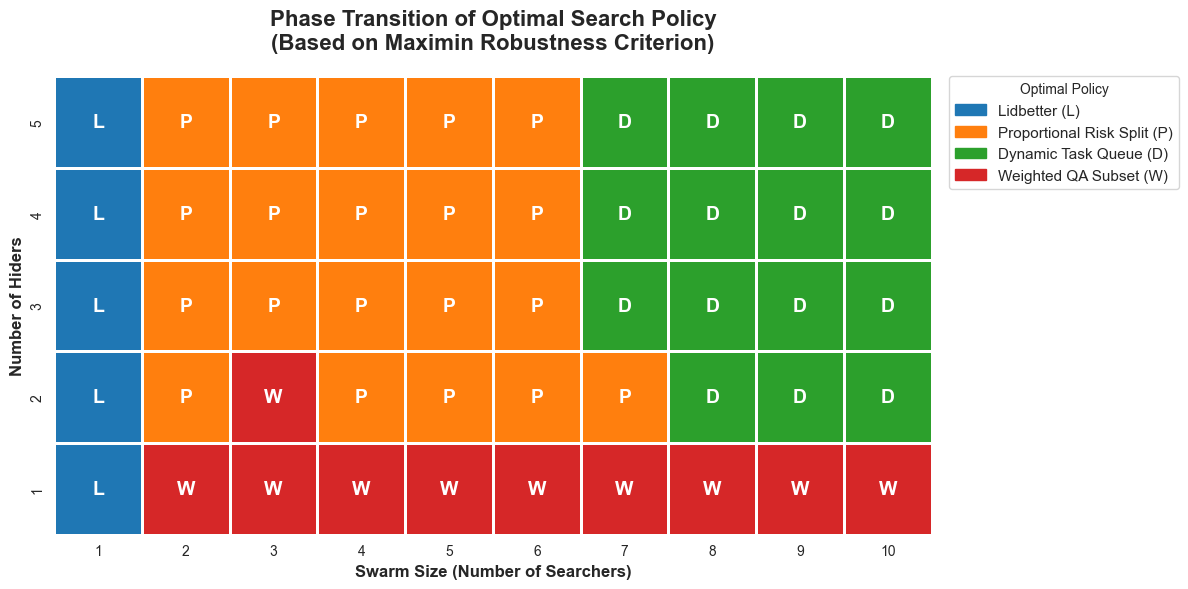

In [67]:
# ==========================================
# COMMANDER'S TOOL: PHASE TRANSITION HEATMAP (UPDATED)
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# 1. CONFIGURATION
# ----------------
TARGET_TACTICS = [
    "Lidbetter",
    "Proportional_risk_split",
    "Dynamic_task_queue",
    "Weighted_qa_subset_sampling",
]

# Map strategies to integer codes for the heatmap
STRATEGY_CODES = {
    "Lidbetter": 0,
    "Proportional_risk_split": 1,
    "Dynamic_task_queue": 2,
    "Weighted_qa_subset_sampling": 3,
}

# Reverse map for labels (for text inside cells)
CODE_TO_STRATEGY = {v: k for k, v in STRATEGY_CODES.items()}

palet_obj = create_palet(4)
CUSTOM_COLORS = [
    # "#1f77b4",  # Lidbetter
    # "#ff7f0e",  # Proportional
    # "#2ca02c",  # Dynamic
    palet_obj[0],
    palet_obj[1],
    palet_obj[2],
    palet_obj[3],
]

DISTS_TO_INCLUDE = [
    'SUCCESS_PROBABILITIES_LOW_VAR',
    'SUCCESS_PROBABILITIES_HIGH_VAR',
    'SUCCESS_PROBABILITIES_SKEWED'
]

# 2. DATA LOADING
# ---------------
df_all_scenarios = pd.DataFrame()
print("Loading data for Phase Transition Heatmap...")

for p_dist in DISTS_TO_INCLUDE:
    try:
        # Use your specific file path logic here
        file_path = f"../data/dataset/{p_dist}/sim_results_dataset.csv"

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)

            # Apply renaming (assuming to_plot_tacts_old and rename_map are defined globally)
            temp_df = temp_df[temp_df['tactic'].isin(to_plot_tacts_old)]
            temp_df['tactic'] = temp_df['tactic'].replace(rename_map)

            # Filter
            temp_df = temp_df[
                (temp_df['tactic'].isin(TARGET_TACTICS)) &
                (temp_df['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
                (temp_df['runs'] == FIXED_NUMBER_OF_RUNS)
                ]

            df_all_scenarios = pd.concat([df_all_scenarios, temp_df], ignore_index=True)

    except Exception as e:
        print(f"Skipping {p_dist}: {e}")

if df_all_scenarios.empty:
    raise ValueError("No data found! Check paths or definitions.")

# 3. COMPUTE WINNERS (THE PHASE TRANSITION)
# -----------------------------------------
# A. Group by (Hiders, Swarm Size, Tactic) -> Calculate Maximin (Min across dists)
grouped = df_all_scenarios.groupby(['n_hiders', 'swarm_size', 'tactic'])['all_found_mean'].min().reset_index()

# B. Find the Best Tactic for each (Hiders, Swarm Size) pair
winners = grouped.sort_values('all_found_mean', ascending=False).drop_duplicates(['n_hiders', 'swarm_size'])

# C. Pivot to Matrix format
heatmap_data = winners.pivot(index='n_hiders', columns='swarm_size', values='tactic')

# Map tactic names to integers
heatmap_numeric = heatmap_data.replace(STRATEGY_CODES).fillna(-1)

# 4. PLOTTING
# -----------
plt.figure(figsize=(12, 6))

# Create discrete colormap from our custom list
cmap = sns.color_palette(CUSTOM_COLORS)

# Draw Heatmap
ax = sns.heatmap(
    heatmap_numeric,
    cmap=cmap,
    annot=True,
    fmt="g",
    cbar=False,
    linewidths=1,
    linecolor='white',
    square=False
)

# 5. FORMATTING LABELS
# --------------------
for text in ax.texts:
    try:
        val = int(text.get_text())
        if val in CODE_TO_STRATEGY:
            # L = Lidbetter, P = Prop Risk, D = Dynamic, W = Weighted
            label = CODE_TO_STRATEGY[val][0]
            text.set_text(label)
            text.set_weight('bold')
            text.set_color('white')
            text.set_fontsize(14)
    except:
        pass

# Axis Labels
plt.title("Phase Transition of Optimal Search Policy\n(Based on Maximin Robustness Criterion)",
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Number of Hiders", fontsize=12, fontweight='bold')
plt.xlabel("Swarm Size (Number of Searchers)", fontsize=12, fontweight='bold')

ax.invert_yaxis()

# 6. CUSTOM LEGEND
# ----------------
# Manually assign the colors matching STRATEGY_CODES indices
legend_patches = [
    mpatches.Patch(color=CUSTOM_COLORS[0], label='Lidbetter (L)'),
    mpatches.Patch(color=CUSTOM_COLORS[1], label='Proportional Risk Split (P)'),
    mpatches.Patch(color=CUSTOM_COLORS[2], label='Dynamic Task Queue (D)'),
    mpatches.Patch(color=CUSTOM_COLORS[3], label='Weighted QA Subset (W)')
]

plt.legend(handles=legend_patches, title="Optimal Policy",
           bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)

plt.tight_layout()

# Save
save_path = os.path.join(PLOT_DIR, "Phase_Transition_Heatmap.svg")
plt.savefig(save_path, bbox_inches='tight')
print(f"Heatmap saved to {save_path}")
plt.show()

Starting Data Loading...

Data Loaded. Total rows: 1728
Generating robustness plot for Strategy: greedy...
Saved plot to: ..\plots\Strategy_Robustness\robustness_strategy_greedy.svg


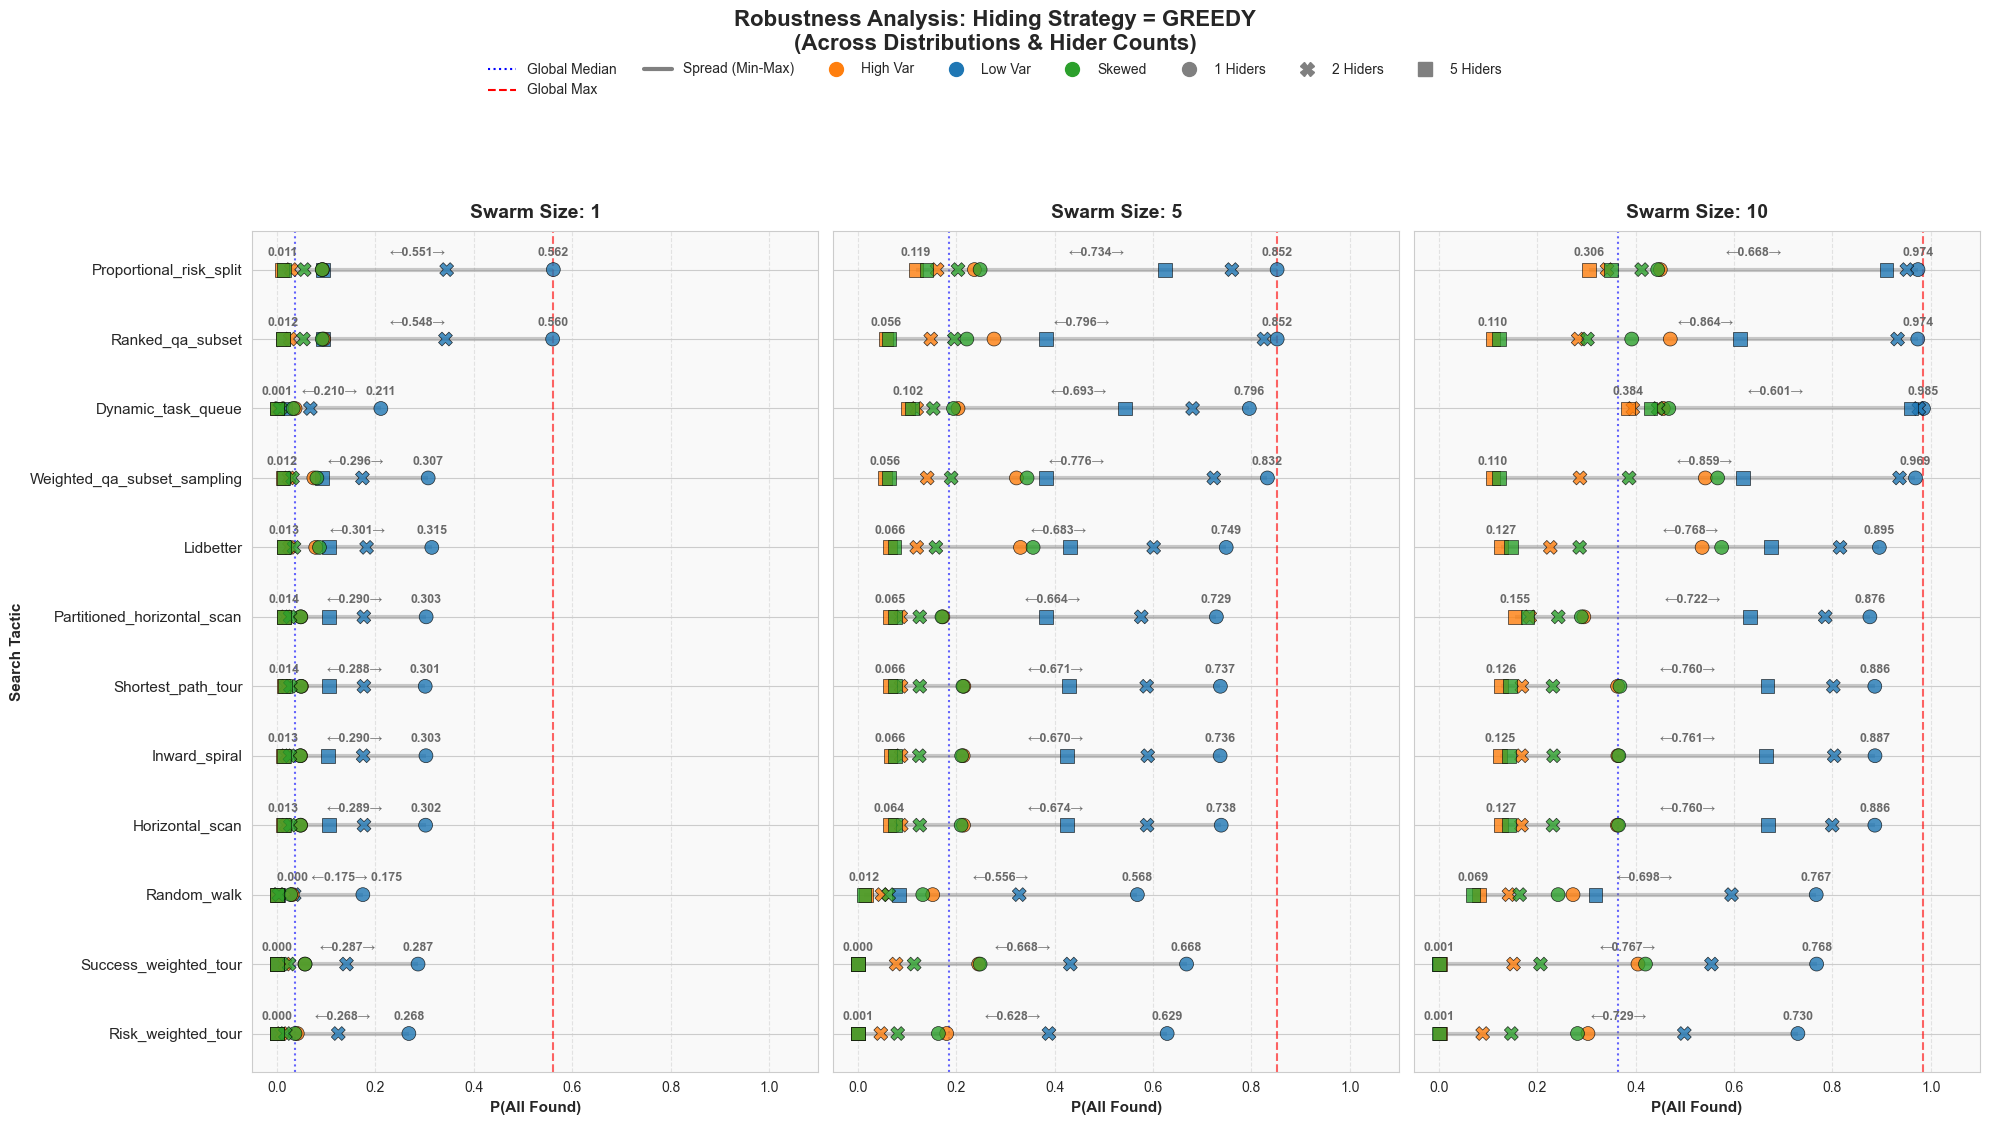

Generating robustness plot for Strategy: random...
Saved plot to: ..\plots\Strategy_Robustness\robustness_strategy_random.svg


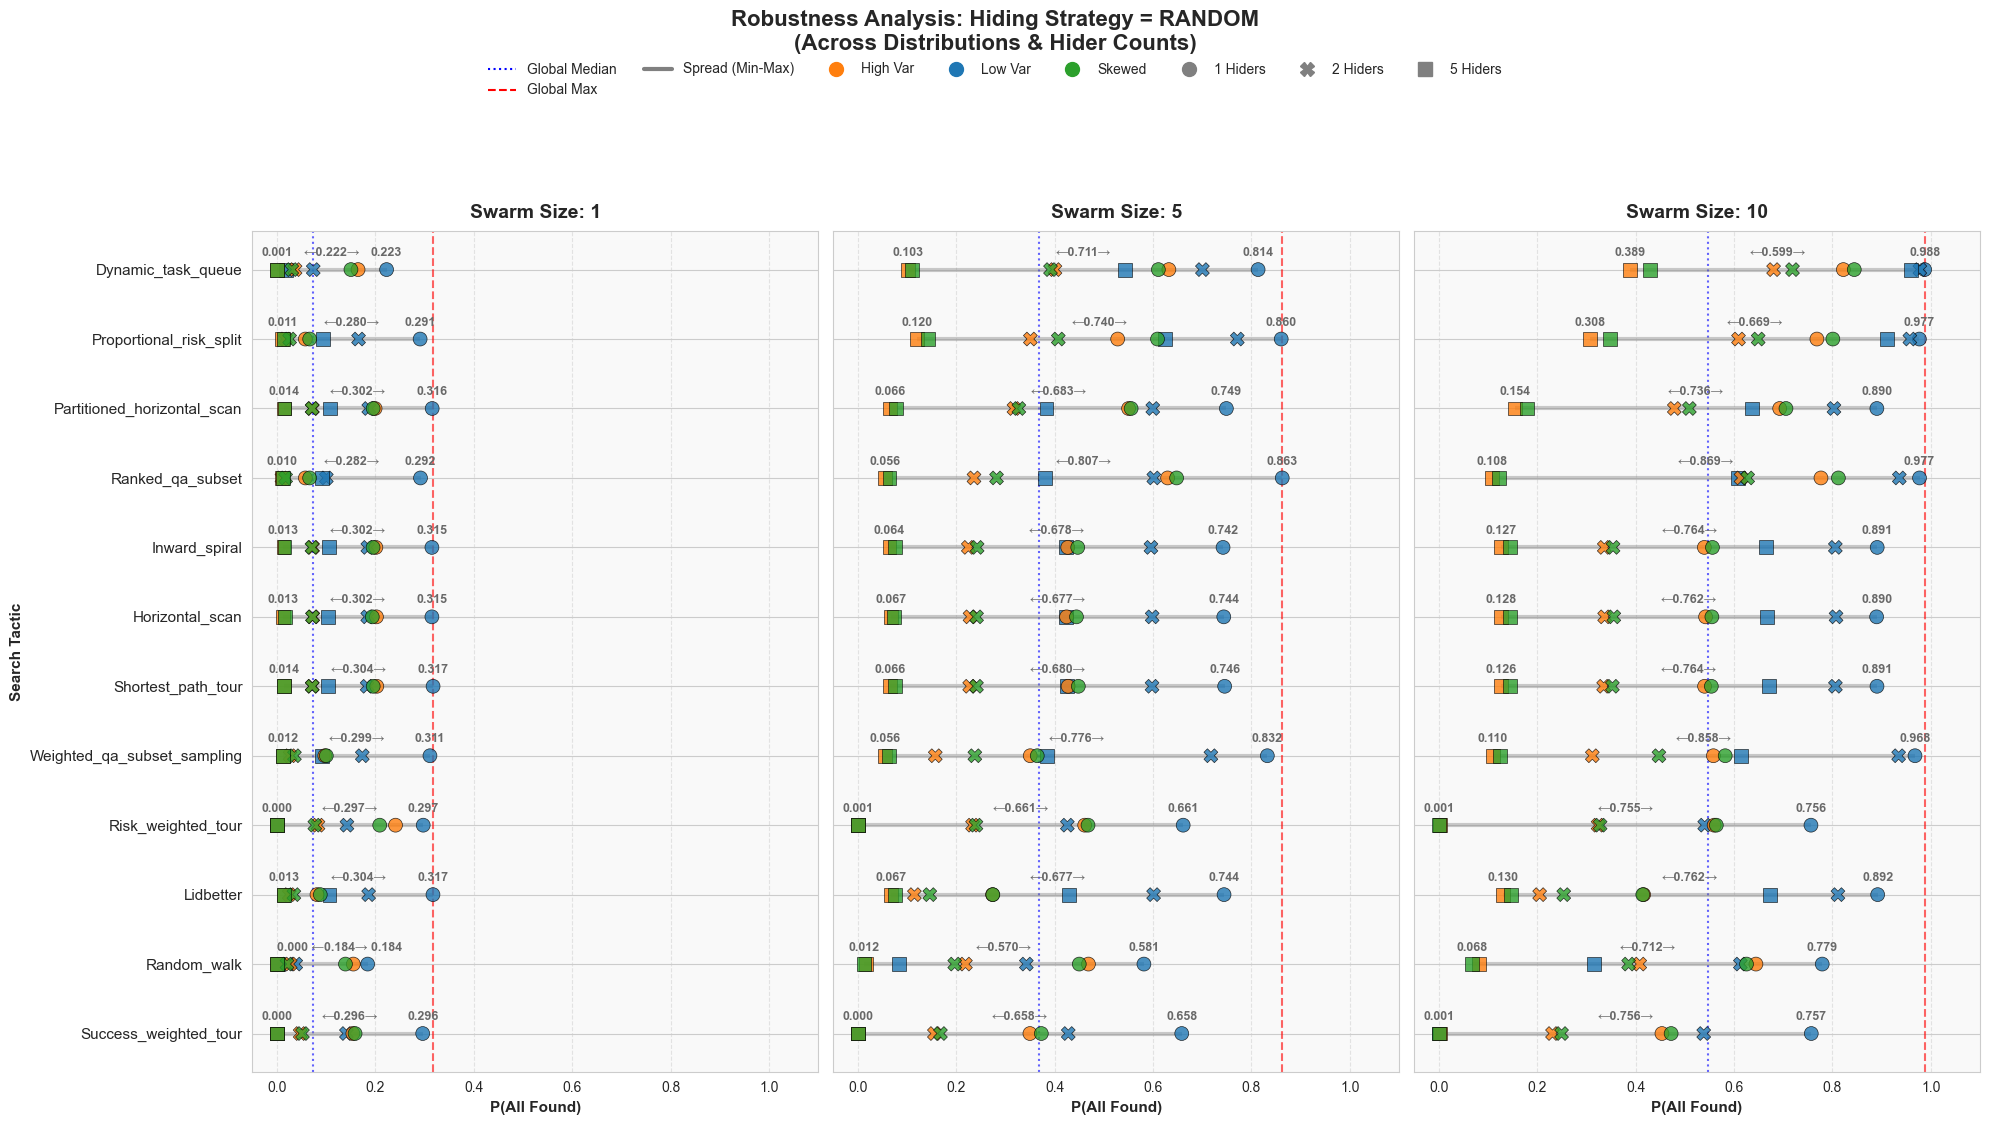

Generating robustness plot for Strategy: weighted...
Saved plot to: ..\plots\Strategy_Robustness\robustness_strategy_weighted.svg


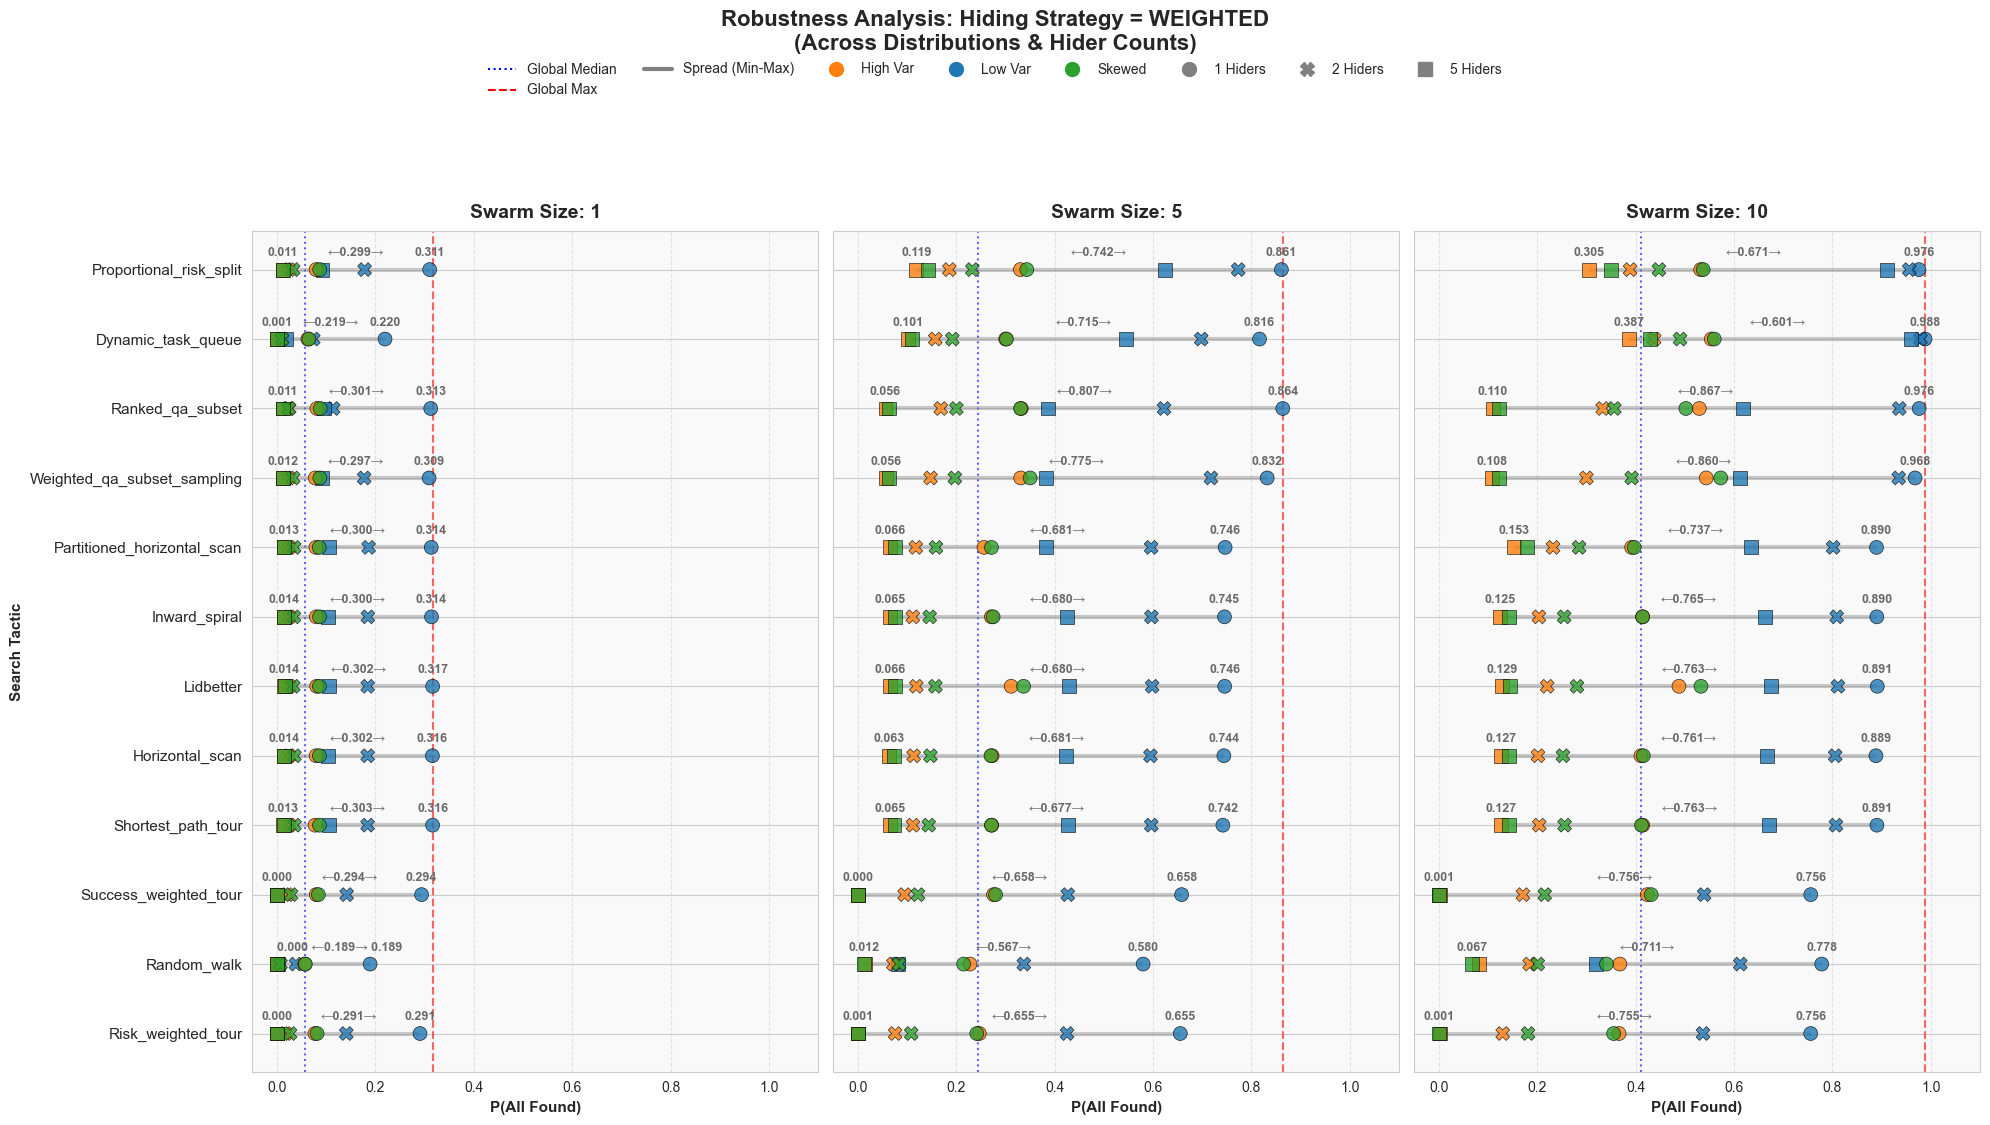

In [57]:
# ==========================================
# 1. DATA EXTRACTION FUNCTION
# ==========================================
def obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist):
    mask = (
        (df_all['hide_strategy'] == hiding_strategy) &
        (df_all['n_hiders'] == n_hiders) &
        (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
        (df_all['grid_width'] == FIXED_GRID_WIDTH) &
        (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
    )

    df_filtered = df_all[mask]

    if df_filtered.empty:
        return None

    results = {}

    for tactic_name in df_filtered['tactic'].unique():
        df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]
        df_tactic = df_tactic.sort_values(by='swarm_size')

        results[tactic_name] = {
            'swarm_sizes': df_tactic['swarm_size'].values,
            'P': df_tactic['all_found_mean'].values,
            'low': df_tactic['all_found_ci_lower'].values,
            'high': df_tactic['all_found_ci_upper'].values
        }

    # Sort results for consistent return order (optional)
    sorted_results = sorted(
        results.items(),
        key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
        reverse=True
    )

    return sorted_results

# ==========================================
# 2. PLOTTING FUNCTION (Strategy-Centric)
# ==========================================
def plot_robustness_for_strategy(df, strategy_name, swarm_sizes=[1, 5, 10]):
    """
    Generates a figure for a SINGLE Hiding Strategy (e.g., Greedy).
    Subplots: Swarm Sizes.
    Hue (Color): Probability Distribution (Environment).
    Style (Shape): Hider Count (Scale).
    """

    # Filter data for the specific hiding strategy
    df = df[(df['Swarm Size'].isin(swarm_sizes)) & (df['Hiding Strategy'] == strategy_name)]

    if df.empty:
        print(f"No data available for Hiding Strategy: {strategy_name}")
        return

    # --- DEFINE COLORS (DISTRIBUTIONS) ---
    unique_dists = sorted(df['Distribution'].unique())
    # Ensure consistent coloring across plots
    # Map specific distributions to specific indices if desired, or just generated
    palet_obj = create_palet(len(unique_dists))

    # Mapping widely used distributions to fixed colors if present
    dist_map_keys = [
        'SUCCESS_PROBABILITIES_LOW_VAR',
        'SUCCESS_PROBABILITIES_HIGH_VAR',
        'SUCCESS_PROBABILITIES_SKEWED'
    ]
    # Fallback if other distributions exist
    dist_colors = {}
    for i, d in enumerate(unique_dists):
        # Try to match to consistent palette positions
        if d in dist_map_keys:
            idx = dist_map_keys.index(d)
            dist_colors[d] = palet_obj[idx % len(palet_obj)]
        else:
            dist_colors[d] = palet_obj[i % len(palet_obj)]

    dist_labels = {
        'SUCCESS_PROBABILITIES_LOW_VAR': 'Low Var',
        'SUCCESS_PROBABILITIES_HIGH_VAR': 'High Var',
        'SUCCESS_PROBABILITIES_SKEWED': 'Skewed'
    }

    # --- DEFINE MARKERS (HIDER COUNTS) ---
    unique_hiders = sorted(df['Hiders'].unique())
    # shapes: o=circle, X=cross, s=square, ^=triangle, D=diamond
    available_markers = ['o', 'X', 's', '^', 'D']
    hider_markers = {h: available_markers[i % len(available_markers)] for i, h in enumerate(unique_hiders)}

    # Sort Tactics by Global Median Score within this Strategy context
    tactic_order = df.groupby('Tactic')['Score'].median().sort_values(ascending=True).index.tolist()

    # Setup Figure
    num_sizes = len(swarm_sizes)
    fig, axes = plt.subplots(nrows=1, ncols=num_sizes, figsize=(20, 10), sharey=True)
    if num_sizes == 1: axes = [axes]

    # --- PLOTTING LOOP ---
    for i, size in enumerate(sorted(swarm_sizes)):
        ax = axes[i]
        subset = df[df['Swarm Size'] == size]

        if subset.empty:
            ax.set_visible(False)
            continue

        # Global Benchmarks for this panel
        global_median = subset['Score'].median()
        global_max = subset['Score'].max()

        # Grid and Background
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        ax.set_facecolor('#f9f9f9')

        # --- 1. PLOT GLOBAL LINES ---
        ax.axvline(x=global_median, color='blue', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        ax.axvline(x=global_max, color='red', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

        # --- 2. DRAW SPREAD LINES AND LABELS ---
        for y_idx, tactic in enumerate(tactic_order):
            tactic_data = subset[subset['Tactic'] == tactic]
            if tactic_data.empty: continue

            min_score = tactic_data['Score'].min()
            max_score = tactic_data['Score'].max()
            spread = max_score - min_score
            midpoint = (min_score + max_score) / 2

            # Draw gray line representing robustness range across Dist & Hiders
            ax.hlines(y=y_idx, xmin=min_score, xmax=max_score,
                      color='gray', alpha=0.4, linewidth=3, zorder=1)

            # Labels
            overlap_threshold = 0.2
            if spread > 0.001:
                if spread < overlap_threshold:
                    combined_text = f"{min_score:.3f} ←{spread:.3f}→ {max_score:.3f}"
                    ax.text(x=min_score, y=y_idx + 0.15, s=combined_text,
                            ha='left', va='bottom', fontsize=9, color='dimgray', fontweight='bold')
                else:
                    ax.text(x=midpoint, y=y_idx + 0.15, s=f"←{spread:.3f}→",
                            ha='center', va='bottom', fontsize=9, color='dimgray', fontweight='bold')
                    ax.text(x=min_score, y=y_idx + 0.15, s=f"{min_score:.3f}",
                            ha='center', va='bottom', fontsize=9, color='dimgray', fontweight='bold')
                    ax.text(x=max_score, y=y_idx + 0.15, s=f"{max_score:.3f}",
                            ha='center', va='bottom', fontsize=9, color='dimgray', fontweight='bold')
            else:
                 # Single point or zero spread
                 ax.text(x=min_score, y=y_idx + 0.15, s=f"{min_score:.3f}",
                         ha='center', va='bottom', fontsize=9, color='dimgray', fontweight='bold')

        # --- 3. PLOT DATA POINTS ---
        subset_copy = subset.copy()
        subset_copy['Tactic_Idx'] = subset_copy['Tactic'].apply(lambda x: tactic_order.index(x) if x in tactic_order else -1)

        sns.scatterplot(
            data=subset_copy,
            x='Score',
            y='Tactic_Idx',
            hue='Distribution',
            style='Hiders',
            palette=dist_colors,
            markers=hider_markers,
            s=100,
            alpha=0.8,
            edgecolor='k',
            linewidth=0.5,
            ax=ax,
            zorder=3,
            legend=False
        )

        ax.set_title(f"Swarm Size: {size}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel("P(All Found)", fontsize=11, fontweight='bold')
        ax.set_xlim(-0.05, 1.1)

        if i == 0:
            ax.set_yticks(range(len(tactic_order)))
            ax.set_yticklabels(tactic_order, fontsize=11)
            ax.set_ylabel("Search Tactic", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.tick_params(left=False)

    # --- CUSTOM LEGEND ---
    # 1. Benchmarks
    median_handle = mlines.Line2D([], [], color='blue', linestyle=':', linewidth=1.5, label='Global Median')
    max_handle = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.5, label='Global Max')
    spread_handle = mlines.Line2D([], [], color='gray', linewidth=3, label='Spread (Min-Max)')

    # 2. Distributions (Color)
    dist_handles = [
        mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                      markersize=10, label=dist_labels.get(d, d))
        for d, color in dist_colors.items() if d in df['Distribution'].unique()
    ]

    # 3. Hiders (Shape)
    # Using black color to represent shape neutral of distribution
    hider_handles = [
        mlines.Line2D([], [], color='grey', marker=marker, linestyle='None',
                      markersize=10, label=f"{h} Hiders")
        for h, marker in hider_markers.items() if h in df['Hiders'].unique()
    ]

    all_handles = [median_handle, max_handle, spread_handle] + dist_handles + hider_handles

    fig.legend(handles=all_handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 1.08),
               ncol=8,
               fontsize=10,
               frameon=False)

    plt.suptitle(f"Robustness Analysis: Hiding Strategy = {strategy_name.upper()}\n(Across Distributions & Hider Counts)",
                 y=1.12, fontsize=16, fontweight='bold')

    output_dir = os.path.join("..", "plots", "Strategy_Robustness")
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, f"robustness_strategy_{strategy_name}.svg")

    plt.tight_layout()
    plt.savefig(file_path, bbox_inches='tight')
    print(f"Saved plot to: {file_path}")
    plt.show()

# ==========================================
# 3. MAIN EXECUTION LOGIC
# ==========================================

all_data_rows = []

# Define configurations
HIDERS_TO_PLOT = [1, 2, 5]
HIDING_STRATEGIES_TO_PLOT = ['greedy', 'random', 'weighted']
PROB_DISTS_TO_PLOT = ['SUCCESS_PROBABILITIES_LOW_VAR', 'SUCCESS_PROBABILITIES_HIGH_VAR', 'SUCCESS_PROBABILITIES_SKEWED']

# Ensure we have the list of old names to filter correctly
to_plot_tacts_old = list(tactic_abbr_full.values())

print("Starting Data Loading...")

for p_dist in PROB_DISTS_TO_PLOT:
    try:
        file_path = get_file_name(p_dist, t="SUMMARY_FILENAME")
        df_all = pd.read_csv(file_path)

        # 1. Filter tactics using OLD names
        df_all = df_all[df_all['tactic'].isin(to_plot_tacts_old)]

        # 2. Rename tactics
        df_all['tactic'] = df_all['tactic'].replace(rename_map)

        # 3. Iterate over variables to extract data
        for hiding_strategy in HIDING_STRATEGIES_TO_PLOT:
            for n_hiders in HIDERS_TO_PLOT:
                res = obtain_right_data_robuustness(df_all, hiding_strategy, n_hiders, p_dist)

                if res:
                    for tactic_name, metrics in res:
                        swarms = metrics['swarm_sizes']
                        scores = metrics['P']

                        for i, swarm_size in enumerate(swarms):
                            all_data_rows.append({
                                'Tactic': tactic_name,
                                'Distribution': p_dist,
                                'Hiding Strategy': hiding_strategy,
                                'Hiders': n_hiders,
                                'Swarm Size': swarm_size,
                                'Score': scores[i]
                            })

    except Exception as e:
        print(f"Error processing {p_dist}: {e}")

# Create Main DataFrame
df_robustness = pd.DataFrame(all_data_rows)

if not df_robustness.empty:
    print(f"\nData Loaded. Total rows: {len(df_robustness)}")

    # Generate 3 Figures: One for each Hiding Strategy
    for strategy in HIDING_STRATEGIES_TO_PLOT:
        print(f"Generating robustness plot for Strategy: {strategy}...")
        plot_robustness_for_strategy(
            df=df_robustness,
            strategy_name=strategy,
            swarm_sizes=[1, 5, 10]
        )
else:
    print("DataFrame is empty. No data found.")

Loading data for Phase Transition Heatmap (Single Dist)...


C:\Users\Janvg\AppData\Local\Temp\ipykernel_17212\2651975707.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_numeric = heatmap_data.replace(STRATEGY_CODES).fillna(-1)


NameError: name 'mpatches' is not defined

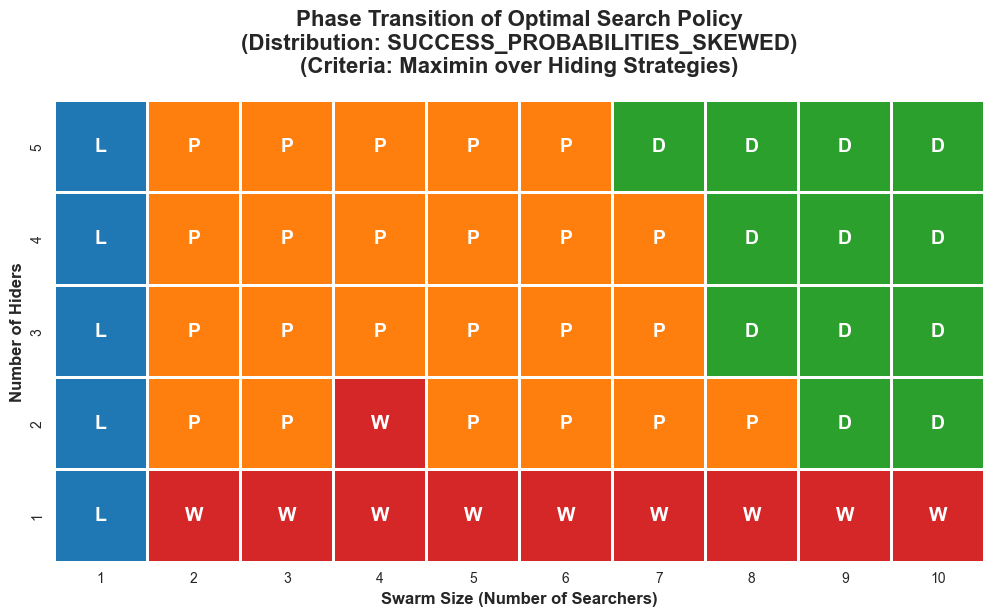

In [13]:
# Options: 'SUCCESS_PROBABILITIES_LOW_VAR', 'SUCCESS_PROBABILITIES_HIGH_VAR', 'SUCCESS_PROBABILITIES_SKEWED'
# Set to None to squash ALL distributions together (original behavior)
# SELECTED_DISTRIBUTION = 'SUCCESS_PROBABILITIES_LOW_VAR'
# SELECTED_DISTRIBUTION = 'SUCCESS_PROBABILITIES_HIGH_VAR'
SELECTED_DISTRIBUTION = 'SUCCESS_PROBABILITIES_SKEWED'
# SELECTED_DISTRIBUTION = None

TARGET_TACTICS = [
    "Lidbetter",
    "Proportional_risk_split",
    "Dynamic_task_queue",
    "Weighted_qa_subset_sampling",
]

# Map strategies to integer codes for the heatmap
STRATEGY_CODES = {
    "Lidbetter": 0,
    "Proportional_risk_split": 1,
    "Dynamic_task_queue": 2,
    "Weighted_qa_subset_sampling": 3,
}

# Reverse map for labels (for text inside cells)
CODE_TO_STRATEGY = {v: k for k, v in STRATEGY_CODES.items()}

# Ensure palette exists (fallback if create_palet is missing from context)
try:
    palet_obj = create_palet(4)
except NameError:
    palet_obj = sns.color_palette("tab10", 4)

CUSTOM_COLORS = [
    palet_obj[0], # Lidbetter
    palet_obj[1], # Proportional
    palet_obj[2], # Dynamic
    palet_obj[3], # Weighted QA
]

# Determine which distributions to load
if SELECTED_DISTRIBUTION:
    DISTS_TO_INCLUDE = [SELECTED_DISTRIBUTION]
    title_suffix = f"\n(Distribution: {SELECTED_DISTRIBUTION})"
    filename_suffix = f"_{SELECTED_DISTRIBUTION}"
else:
    DISTS_TO_INCLUDE = [
        'SUCCESS_PROBABILITIES_LOW_VAR',
        'SUCCESS_PROBABILITIES_HIGH_VAR',
        'SUCCESS_PROBABILITIES_SKEWED'
    ]
    title_suffix = "\n(Robustness across ALL Distributions)"
    filename_suffix = "_ALL_DISTS"

# 2. DATA LOADING
# ---------------
df_all_scenarios = pd.DataFrame()
print(f"Loading data for Phase Transition Heatmap ({'Single Dist' if SELECTED_DISTRIBUTION else 'All Dists'})...")

for p_dist in DISTS_TO_INCLUDE:
    try:
        file_path = f"../data/dataset/{p_dist}/sim_results_dataset.csv"

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)

            # Apply renaming (assuming to_plot_tacts_old and rename_map are defined globally)
            # If not defined in this block, ensure they exist in your notebook environment
            if 'to_plot_tacts_old' in globals() and 'rename_map' in globals():
                temp_df = temp_df[temp_df['tactic'].isin(to_plot_tacts_old)]
                temp_df['tactic'] = temp_df['tactic'].replace(rename_map)

            # Filter
            temp_df = temp_df[
                (temp_df['tactic'].isin(TARGET_TACTICS)) &
                (temp_df['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
                (temp_df['runs'] == FIXED_NUMBER_OF_RUNS)
                ]

            df_all_scenarios = pd.concat([df_all_scenarios, temp_df], ignore_index=True)

    except Exception as e:
        print(f"Skipping {p_dist}: {e}")

if df_all_scenarios.empty:
    raise ValueError("No data found! Check paths or definitions.")

# 3. COMPUTE WINNERS (THE PHASE TRANSITION)
# -----------------------------------------
# A. Group by (Hiders, Swarm Size, Tactic) -> Calculate Maximin (Min P(found))
#    If a specific distribution is selected, this calculates the MINIMUM success
#    across the different HIDING STRATEGIES (Greedy, Random, Weighted).
grouped = df_all_scenarios.groupby(['n_hiders', 'swarm_size', 'tactic'])['all_found_mean'].min().reset_index()

# B. Find the Best Tactic for each (Hiders, Swarm Size) pair
#    We sort by score descending and take the top one.
winners = grouped.sort_values('all_found_mean', ascending=False).drop_duplicates(['n_hiders', 'swarm_size'])

# C. Pivot to Matrix format
heatmap_data = winners.pivot(index='n_hiders', columns='swarm_size', values='tactic')

# Map tactic names to integers
heatmap_numeric = heatmap_data.replace(STRATEGY_CODES).fillna(-1)

# 4. PLOTTING
# -----------
plt.figure(figsize=(12, 6))

# Create discrete colormap from our custom list
cmap = sns.color_palette(CUSTOM_COLORS)

# Draw Heatmap
ax = sns.heatmap(
    heatmap_numeric,
    cmap=cmap,
    annot=True,
    fmt="g",
    cbar=False,
    linewidths=1,
    linecolor='white',
    square=False
)

# 5. FORMATTING LABELS
# --------------------
for text in ax.texts:
    try:
        val = int(text.get_text())
        if val in CODE_TO_STRATEGY:
            # L = Lidbetter, P = Prop Risk, D = Dynamic, W = Weighted
            label = CODE_TO_STRATEGY[val][0]
            text.set_text(label)
            text.set_weight('bold')
            text.set_color('white')
            text.set_fontsize(14)
    except:
        pass

# Axis Labels
plt.title(f"Phase Transition of Optimal Search Policy{title_suffix}\n(Criteria: Maximin over Hiding Strategies)",
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Number of Hiders", fontsize=12, fontweight='bold')
plt.xlabel("Swarm Size (Number of Searchers)", fontsize=12, fontweight='bold')

ax.invert_yaxis()

# 6. CUSTOM LEGEND
# ----------------
legend_patches = [
    mpatches.Patch(color=CUSTOM_COLORS[0], label='Lidbetter (L)'),
    mpatches.Patch(color=CUSTOM_COLORS[1], label='Proportional Risk Split (P)'),
    mpatches.Patch(color=CUSTOM_COLORS[2], label='Dynamic Task Queue (D)'),
    mpatches.Patch(color=CUSTOM_COLORS[3], label='Weighted QA Subset (W)')
]

plt.legend(handles=legend_patches, title="Optimal Policy",
           bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)

plt.tight_layout()

# Save
save_path = os.path.join(PLOT_DIR, f"Phase_Transition_Heatmap{filename_suffix}.svg")
plt.savefig(save_path, bbox_inches='tight')
print(f"Heatmap saved to {save_path}")
plt.show()

C:\Users\Janvg\AppData\Local\Temp\ipykernel_4828\507462664.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


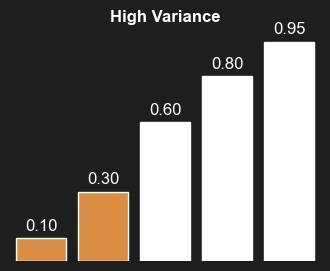

C:\Users\Janvg\AppData\Local\Temp\ipykernel_4828\507462664.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


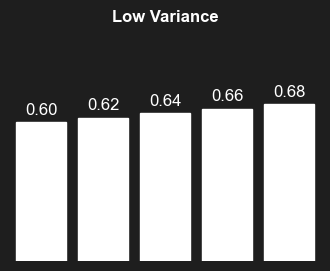

C:\Users\Janvg\AppData\Local\Temp\ipykernel_4828\507462664.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


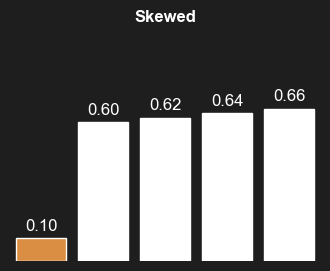

In [4]:
SUCCESS_PROBABILITIES_HIGH_VAR = [0.10, 0.30, 0.60, 0.80, 0.95]
SUCCESS_PROBABILITIES_LOW_VAR  = [0.60, 0.62, 0.64, 0.66, 0.68]
SUCCESS_PROBABILITIES_SKEWED   = [0.10,0.60, 0.62, 0.64, 0.66]

palet_obj = create_palet(2)


def plot_distribution(values, highlight_mask, title):
    bg_color = "#1e1e1e"
    white = "#ffffff"
    orange = "#f28e2b"

    colors = [orange if h else white for h in highlight_mask]

    plt.figure(figsize=(4, 3), facecolor=bg_color)
    ax = plt.gca()
    ax.set_facecolor(bg_color)

    sns.barplot(
        x=list(range(len(values))),
        y=values,
        palette=colors,
        ax=ax
    )

    # Title
    ax.set_title(title, color="white", fontweight='bold')

    # Limits
    ax.set_ylim(0, 1)

    # Remove axes
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Value labels
    for bar, val in zip(ax.patches, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=12,
            color="white"
        )
    plt.savefig(f"./presentation_dist_{title}.svg", bbox_inches='tight')
    plt.show()
plot_distribution(
    SUCCESS_PROBABILITIES_HIGH_VAR,
    highlight_mask=[True, True, False, False, False],
    title="High Variance"
)
plot_distribution(
    SUCCESS_PROBABILITIES_LOW_VAR,
    highlight_mask=[False] * 5,
    title="Low Variance"
)
plot_distribution(
    SUCCESS_PROBABILITIES_SKEWED,
    highlight_mask=[True,False, False, False, False],
    title="Skewed"
)

